In [74]:
import dPCA.dPCA
print(dir(dPCA.dPCA))

['BaseEstimator', 'OrderedDict', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'chain', 'classification', 'combinations', 'dPCA', 'denoise_mask', 'ne', 'np', 'pinv', 'print_function', 'randomized_svd', 'shuffle2D', 'svds']


In [2]:
import numpy as np
from numpy import *
import matplotlib.pyplot as plt
from dPCA import dPCA
from mpl_toolkits.mplot3d import Axes3D
from numpy.random import rand, randn, randint

# Import the data

In [3]:
def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions = load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

In [4]:
s0 = sessions[0]

In [5]:
# Basic stats for session 0
stats = {
    "session_id": 0,
    "mouse": s0.get("mouse"),
    "run_number": s0.get("run_number"),
    "name": s0.get("name"),
    "n_cells": s0.get("n_cells"),
    "n_trials": s0.get("n_trials"),
    "n_times": s0.get("n_times"),
    "frequency": s0.get("frequency"),
}
print("Session 0 stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")

# Outcomes summary
outcomes = np.asarray(s0.get("outcome"))
print("\nOutcome values (unique):", np.unique(outcomes))

# Count outcomes (handles numeric or string labels)
if outcomes.dtype.kind in {"U", "S", "O"}:
    labels, counts = np.unique(outcomes, return_counts=True)
    print("Outcome counts:")
    for label, count in zip(labels, counts):
        print(f"  {label}: {count}")
else:
    # numeric outcomes; include total and per-value counts
    values, counts = np.unique(outcomes, return_counts=True)
    print("Outcome counts:")
    for value, count in zip(values, counts):
        print(f"  {value}: {count}")
    print(f"  total: {outcomes.size}")

# Target vs non-target summary
is_target = np.asarray(s0.get("is_target"))
if is_target.size:
    targets = np.sum(is_target.astype(bool))
    print(f"\nTargets: {targets} / {is_target.size}")

Session 0 stats:
  session_id: 0
  mouse: J064
  run_number: 10
  name: Mouse J064, run 10
  n_cells: 471
  n_trials: 162
  n_times: 420
  frequency: 30.0

Outcome values (unique): ['arm' 'cr' 'fp' 'hit' 'miss' 'urh']
Outcome counts:
  arm: 2
  cr: 31
  fp: 28
  hit: 79
  miss: 16
  urh: 6

Targets: 4968180 / 32046840


In [6]:
print(f"Timepoints per trial: {s0['n_times']}")

Timepoints per trial: 420


In [5]:
import time
import builtins # Force built-in min
from dPCA import dPCA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.patches as mpatches

# --- 1. Data Preparation (80/20 Split) ---
start_time = time.time()

# Extract data
neural_data = s0['behaviour_trials']  # (N, n_trials, T)
trial_subsets = s0['trial_subsets']   # Magnitude of stim per trial
n_trials = s0['n_trials']

# Split indices (Chronological 80/20)
split_idx = int(0.8 * n_trials)
train_indices = np.arange(split_idx)
test_indices = np.arange(split_idx, n_trials)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")

# Prepare dPCA data (Balanced design from Training set)
unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices) 
                         for cond in unique_conditions}
# Use builtins.min explicitely to handle generator/list correctly regardless of imports
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s0['n_cells'], s0['n_times']
S = len(unique_conditions)

# Construct trialR for dPCA (min_trials_train, N, S, T)
trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    # Select first 'min_trials_train' available in training set for this condition
    selected_trials = trials_per_cond_train[cond][:min_trials_train]
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

# Averaged R (N, S, T)
R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA Data Prepared. Shape: {trialR.shape}")
print(f"Preparation time: {time.time() - start_time:.4f}s")

Data Split: 129 Training trials, 33 Test trials
dPCA Data Prepared. Shape: (5, 471, 8, 420)
Preparation time: 0.0206s


In [6]:
t0 = time.time()

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)

print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3


Starting trial  2 / 3
Starting trial  3 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0006299831412818761
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting time: 9.5743s
Optimized regularization, optimal lambda =  0.0006299831412818761
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting time: 9.5743s


## Shuffle test (stimulus + interaction)
We shuffle the balanced trial labels, refit dPCA with a fixed regularizer, and compare explained variance for stimulus ($s$) and interaction ($s\times t$). The histograms show the shuffled distribution with the true variance and a shuffle-based $p$-value.

Running 100 shuffles...


Shuffle Test Time: 7.9299s


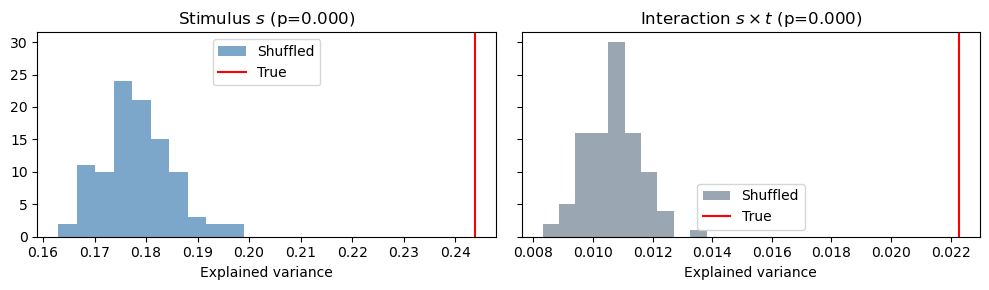

In [7]:
t0 = time.time()

n_shuffles = 100
shuffled_vars_s = []
shuffled_vars_st = []
true_var_s = np.sum(dpca.explained_variance_ratio_.get('s', np.array([0.0])))
true_var_st = np.sum(dpca.explained_variance_ratio_.get('st', np.array([0.0])))

trials_flat = trialR.reshape(-1, N, T)
labels_flat = np.repeat(np.arange(S), min_trials_train)

print(f"Running {n_shuffles} shuffles...")
for _ in range(n_shuffles):
    shuffled_labels = np.random.permutation(labels_flat)

    R_shuff = np.zeros((N, S, T))
    for s in range(S):
        idxs = np.where(shuffled_labels == s)[0]
        R_shuff[:, s, :] = np.mean(trials_flat[idxs], axis=0)

    R_shuff_centered = R_shuff - np.mean(R_shuff.reshape((N, -1)), axis=1)[:, None, None]

    dpca_shuff = dPCA.dPCA(labels='st', regularizer=dpca.regularizer, n_components=10)
    dpca_shuff.protect = ['t']
    dpca_shuff.fit_transform(R_shuff_centered, trialR)

    shuffled_vars_s.append(np.sum(dpca_shuff.explained_variance_ratio_.get('s', np.array([0.0]))))
    shuffled_vars_st.append(np.sum(dpca_shuff.explained_variance_ratio_.get('st', np.array([0.0]))))

p_val_s = np.mean(np.array(shuffled_vars_s) >= true_var_s)
p_val_st = np.mean(np.array(shuffled_vars_st) >= true_var_st)
print(f"Shuffle Test Time: {time.time() - t0:.4f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(shuffled_vars_s, color="steelblue", alpha=0.7, label="Shuffled")
axes[0].axvline(true_var_s, color="r", label="True")
axes[0].set_title(f"Stimulus $s$ (p={p_val_s:.3f})")
axes[0].set_xlabel("Explained variance")
axes[0].legend()

axes[1].hist(shuffled_vars_st, color="slategray", alpha=0.7, label="Shuffled")
axes[1].axvline(true_var_st, color="r", label="True")
axes[1].set_title(f"Interaction $s\\times t$ (p={p_val_st:.3f})")
axes[1].set_xlabel("Explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

# Kalman Filter with Control Inputs

## Mathematical Formulation

We model the temporal evolution of the **neural population state** (represented by the top 10 dPCA components) using a **Linear Dynamical System (LDS)** with control inputs.

### 1. State Space Model

Let $z_t \in \mathbb{R}^{10}$ be the latent state vector (dPCA components) at time step $t$.
Let $u_t \in \mathbb{R}^{1}$ be the control input vector (photostimulation magnitude) at time step $t$.

The system evolves according to the linear equation:

$$ z_t = A z_{t-1} + B u_t + w_t $$

where:
*   $A \in \mathbb{R}^{10 \times 10}$ is the **State Transition Matrix**, governing the autonomous dynamics.
*   $B \in \mathbb{R}^{10 \times 1}$ is the **Control Matrix**, mapping external inputs (stimulation) to state changes.
*   $w_t \sim \mathcal{N}(0, Q)$ is the **Process Noise** (Gaussian), with covariance $Q$.

The states are "observed" through the neural activity (or in our case, we treat the dPCA projection as the ground truth state we want to model). Since we already dimensionally reduced the data to $z$, we can formulate the filter directly in the latent space (treating $z$ as observed during training to find $A, B$) or treat the full neural population $y_t$ as the observation:

$$ y_t = C z_t + v_t $$

where:
*   $y_t \in \mathbb{R}^{N}$ is the neural activity.
*   $C \in \mathbb{R}^{N \times 10}$ is the **Observation Matrix** (equivalent to the dPCA decoder).
*   $v_t \sim \mathcal{N}(0, R)$ is the **Observation Noise**.

### 2. Parameter Learning (Training Phase)

We estimate the matrices $A$, $B$, $C$, $Q$, $R$ using the **Training Data (first 80%)**.

1.  **Latent State Extraction**: Project all training trials into dPCA space to get sequences $Z^{(k)} = [z_0, \dots, z_T]$ for trial $k$.
2.  **Least Squares Optimization**:
    We form the regression problem to minimize the one-step prediction error:
    $$ \min_{A, B} \sum_{k, t} \| z_t^{(k)} - (A z_{t-1}^{(k)} + B u_t^{(k)}) \|^2 $$
    This is solved by linear regression of current states on previous states + inputs.
3.  **Noise Covariance**:
    $Q = \text{Cov}(z_t - (A z_{t-1} + B u_t))$
    $R$ is not explicitly needed if we are predicting $z$, but if we predict $y$, we need $C$ (from dPCA) and can estimate $R$.

### 3. Prediction (Test Phase)

For the **Test Data (last 20%)**, we run the Kalman Filter (or Predictor) to estimate the trajectory $\hat{z}_t$.

For a pure **Generalization Test**, we can perform **Open-Loop Prediction** (Simulation):
Given the initial state $z_0$ and the sequence of inputs $u_{1:T}$, we iterate:
$$ \hat{z}_t = A \hat{z}_{t-1} + B u_t $$
This ignores the neural data during the trial (no correction), testing if the learned dynamics $A$ and Control $B$ truly capture the system's behavior.

We can also run the full **Closed-Loop Kalman Filter**:
$$ \hat{z}_{t|t-1} = A \hat{z}_{t-1|t-1} + B u_t $$
$$ P_{t|t-1} = A P_{t-1|t-1} A^T + Q $$
$$ K_t = P_{t|t-1} C^T (C P_{t|t-1} C^T + R)^{-1} $$
$$ \hat{z}_{t|t} = \hat{z}_{t|t-1} + K_t (y_t - C \hat{z}_{t|t-1}) $$
$$ P_{t|t} = (I - K_t C) P_{t|t-1} $$

We will compare the **Open-Loop Prediction** (generative model quality) against a **Naive Baseline** (persisting the mean state or zero dynamics).

### Metrics
We define goodness of fit using $R^2$ (Coefficient of Determination) and MSE (Mean Squared Error) on the predicted neural data $\hat{y} = C\hat{z}$.

## Kalman training + inference (timed)

We fit a linear state model in dPCA space with control inputs, then evaluate open-loop predictions on the test set. The key outputs are **training time** and **inference time (total + per trial)**.

**Training steps**
- Build a 10D projection from the highest-variance dPCA components.
- Project all trials into latent space and center by the training mean.
- Encode the stimulus as a single-step impulse in $u_t$.
- Solve $z_t = A z_{t-1} + B u_t$ via ridge regression.

In [23]:
from sklearn.linear_model import Ridge

train_start = time.time()
time_axis = s0["filter_ps_time"]

all_components = []
for key in dpca.P.keys():
    for i in range(dpca.P[key].shape[1]):
        var = dpca.explained_variance_ratio_[key][i]
        all_components.append({
            "var": var,
            "key": key,
            "P": dpca.P[key][:, i],
            "D": dpca.D[key][:, i],
        })

all_components.sort(key=lambda x: x["var"], reverse=True)
top_k = 10
P_matrix = np.array([c["P"] for c in all_components[:top_k]]).T
D_matrix = np.array([c["D"] for c in all_components[:top_k]]).T

X_all = neural_data.transpose(1, 2, 0)
X_mean = np.mean(neural_data[:, train_indices, :], axis=(1, 2))
X_centered = X_all - X_mean[None, None, :]
Z_all = X_centered @ P_matrix

stim_idx_start = np.argmin(np.abs(time_axis - 0))
U_all = np.zeros((n_trials, T, 1))
U_all[:, stim_idx_start, 0] = trial_subsets

X_reg = []
Y_reg = []
for tr in train_indices:
    z_b = Z_all[tr, :-1, :]
    u_b = U_all[tr, 1:, :]
    z_f = Z_all[tr, 1:, :]
    X_reg.append(np.hstack([z_b, u_b]))
    Y_reg.append(z_f)

X_reg = np.vstack(X_reg)
Y_reg = np.vstack(Y_reg)

reg = Ridge(alpha=1e-5, fit_intercept=False)
reg.fit(X_reg, Y_reg)

AB_matrix = reg.coef_
A_est = AB_matrix[:, :10]
B_est = AB_matrix[:, 10:]

# Estimate Q (Process Noise Covariance) from training residuals
Y_pred_train = reg.predict(X_reg)
residuals = Y_reg - Y_pred_train
Q_est = np.cov(residuals, rowvar=False)

# Estimate R (Observation Noise Covariance)
# Since we treat dPCA states as observations, we can heuristicall set R.
# A "Balanced" filter trusts dynamics and measurements roughly equally.
# We set R = Q as a baseline "Traditional" KF setup.
R_est = Q_est.copy()

train_time = time.time() - train_start
print("Transition Matrix A shape:", A_est.shape)
print("Control Matrix B shape:", B_est.shape)
print("Q_est shape:", Q_est.shape)
print(f"Kalman training time: {train_time:.4f}s")

Transition Matrix A shape: (10, 10)
Control Matrix B shape: (10, 1)
Q_est shape: (10, 10)
Kalman training time: 0.0970s


## Kalman inference (timed)
We run open-loop predictions on stimulated test trials, report total inference time and per-trial time, and compare against a naive baseline using MSE and $R^2$.

Evaluating on 18 stimulated test trials (out of 33 total test trials).
Non-stim test trials: 15
Evaluation Window Indices: 239 to 420
Time Window: 0.000s to 6.000s
Kalman inference time: 0.1709s
Inference time per trial: 0.009493s
--------------------------------------------------
GLOBAL METRICS (Concatenated Stim Trials | All Latent Dims)
Window: Stim Onset to Stim + 5
--------------------------------------------------
Global Open-Loop MSE:   1.8658
Global Closed-Loop MSE: 0.1575
Global Naive MSE:       5.4411
Global Open-Loop R2 (Var-Weighted):   0.1420
Global Closed-Loop R2 (Var-Weighted): 0.9276
Global Naive R2 (Var-Weighted):       -1.5020
--------------------------------------------------
Window: Stim Onset to End
--------------------------------------------------
Global Open-Loop MSE:   2.3604
Global Closed-Loop MSE: 0.0431
Global Naive MSE:       0.5902
Global Open-Loop R2 (Var-Weighted):   0.2085
Global Closed-Loop R2 (Var-Weighted): 0.9855
Global Naive R2 (Var-Weighted):     

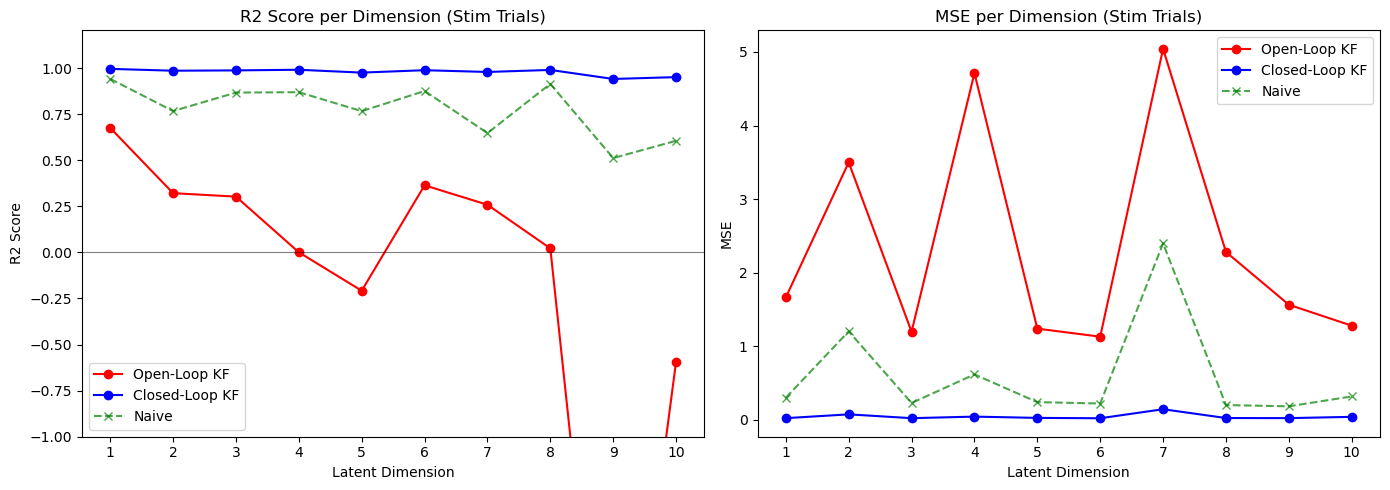

--------------------------------------------------
--------------------------------------------------
GLOBAL METRICS (Concatenated Non-Stim Trials | All Latent Dims)
Window: Stim Onset to Stim + 5
--------------------------------------------------
Global Open-Loop MSE:   0.2960
Global Closed-Loop MSE: 0.0334
Global Naive MSE:       0.2804
Global Open-Loop R2 (Var-Weighted):   0.6611
Global Closed-Loop R2 (Var-Weighted): 0.9618
Global Naive R2 (Var-Weighted):       0.6789
--------------------------------------------------
Window: Stim Onset to End
--------------------------------------------------
Global Open-Loop MSE:   1.6906
Global Closed-Loop MSE: 0.0302
Global Naive MSE:       0.2643
Global Open-Loop R2 (Var-Weighted):   -0.7313
Global Closed-Loop R2 (Var-Weighted): 0.9691
Global Naive R2 (Var-Weighted):       0.7293
--------------------------------------------------


In [31]:
import builtins

inference_start = time.time()

mse_scores = []
r2_scores = []
mse_naive = []
r2_naive = []
mse_closed = []
r2_closed = []

cl_inference_total = 0.0

y_true_stim_list = []
y_pred_stim_list = []
y_closed_stim_list = []
y_naive_stim_list = []

mse_scores_ns = []
r2_scores_ns = []
mse_naive_ns = []
r2_naive_ns = []
mse_closed_ns = []
r2_closed_ns = []

y_true_ns_list = []
y_pred_ns_list = []
y_closed_ns_list = []
y_naive_ns_list = []

# New lists for short window (5 timesteps after stim)
y_true_stim_short = []
y_pred_stim_short = []
y_closed_stim_short = []
y_naive_stim_short = []

y_true_ns_short = []
y_pred_ns_short = []
y_closed_ns_short = []
y_naive_ns_short = []

stim_test_indices = [tr for tr in test_indices if trial_subsets[tr] > 0]
nonstim_test_indices = [tr for tr in test_indices if trial_subsets[tr] == 0]
print(f"Evaluating on {len(stim_test_indices)} stimulated test trials (out of {len(test_indices)} total test trials).")
print(f"Non-stim test trials: {len(nonstim_test_indices)}")

stim_idx_start = np.argmin(np.abs(time_axis - 0))
eval_window_start = stim_idx_start
eval_window_end = T
print(f"Evaluation Window Indices: {eval_window_start} to {eval_window_end}")
print(f"Time Window: {time_axis[eval_window_start]:.3f}s to {time_axis[eval_window_end-1]:.3f}s")

naive_lag = 5

for tr in test_indices:
    z_true = Z_all[tr]
    u_tr = U_all[tr]

    # KF Prediction (Primed Open-Loop)
    # Prime with ground truth up to stimulation, then predict open-loop
    z_pred = np.zeros_like(z_true)
    z_pred[:stim_idx_start] = z_true[:stim_idx_start]
    
    # Start predicting from stim_idx_start using the last ground truth state at (stim_idx_start - 1)
    # If stim_idx_start is 0, we just set z_pred[0] = z_true[0] and loop from 1
    start_t = stim_idx_start if stim_idx_start > 0 else 1
    if start_t == 1: z_pred[0] = z_true[0]

    for t in range(start_t, T):
        z_pred[t] = A_est @ z_pred[t-1] + B_est @ u_tr[t]

    # KF Prediction (Traditional Closed-Loop with Kalman Gain)
    # Uses Q_est and R_est
    from numpy.linalg import inv
    z_closed = np.zeros_like(z_true)
    z_closed[0] = z_true[0]
    P = Q_est.copy() # Initial covariance
    I_mat = np.eye(A_est.shape[0])

    for t in range(1, T):
        # 1. Predict
        z_pred_step = A_est @ z_closed[t-1] + B_est @ u_tr[t]
        P_pred = A_est @ P @ A_est.T + Q_est
        
        # 2. Update (Observation is z_true[t])
        # Model: z_obs = z_state + v, so H=I
        S = P_pred + R_est
        K = P_pred @ inv(S)
        
        innovation = z_true[t] - z_pred_step
        z_closed[t] = z_pred_step + K @ innovation
        P = (I_mat - K) @ P_pred

    # Naive Lag-5 Prediction (Value from 5 timesteps ago)
    z_naive = np.empty_like(z_true)
    z_naive[:naive_lag] = z_true[0] # Persist initial state for first few steps
    z_naive[naive_lag:] = z_true[:-naive_lag]

    # Use all latent dimensions for evaluation
    y_true_win = z_true[eval_window_start:eval_window_end, :]
    y_pred_win = z_pred[eval_window_start:eval_window_end, :]
    y_closed_win = z_closed[eval_window_start:eval_window_end, :]
    y_naive_win = z_naive[eval_window_start:eval_window_end, :]

    # Extract short window data (5 steps after stim onset)
    short_end = builtins.min(T, eval_window_start + 5)
    y_true_s = z_true[eval_window_start:short_end, :]
    y_pred_s = z_pred[eval_window_start:short_end, :]
    y_closed_s = z_closed[eval_window_start:short_end, :]
    y_naive_s = z_naive[eval_window_start:short_end, :]

    if trial_subsets[tr] > 0:
        mse_scores.append(mean_squared_error(y_true_win, y_pred_win))
        r2_scores.append(r2_score(y_true_win, y_pred_win))
        mse_closed.append(mean_squared_error(y_true_win, y_closed_win))
        r2_closed.append(r2_score(y_true_win, y_closed_win))
        mse_naive.append(mean_squared_error(y_true_win, y_naive_win))
        r2_naive.append(r2_score(y_true_win, y_naive_win))
        
        y_true_stim_list.append(y_true_win)
        y_pred_stim_list.append(y_pred_win)
        y_closed_stim_list.append(y_closed_win)
        y_naive_stim_list.append(y_naive_win)

        y_true_stim_short.append(y_true_s)
        y_pred_stim_short.append(y_pred_s)
        y_closed_stim_short.append(y_closed_s)
        y_naive_stim_short.append(y_naive_s)
    else:
        mse_scores_ns.append(mean_squared_error(y_true_win, y_pred_win))
        r2_scores_ns.append(r2_score(y_true_win, y_pred_win))
        mse_closed_ns.append(mean_squared_error(y_true_win, y_closed_win))
        r2_closed_ns.append(r2_score(y_true_win, y_closed_win))
        mse_naive_ns.append(mean_squared_error(y_true_win, y_naive_win))
        r2_naive_ns.append(r2_score(y_true_win, y_naive_win))

        y_true_ns_list.append(y_true_win)
        y_pred_ns_list.append(y_pred_win)
        y_closed_ns_list.append(y_closed_win)
        y_naive_ns_list.append(y_naive_win)
        
        y_true_ns_short.append(y_true_s)
        y_pred_ns_short.append(y_pred_s)
        y_closed_ns_short.append(y_closed_s)
        y_naive_ns_short.append(y_naive_s)

inference_time = time.time() - inference_start
per_trial_time = (inference_time / len(stim_test_indices)) if stim_test_indices else float("nan")
cl_per_trial = cl_inference_total / len(test_indices) if len(test_indices) > 0 else 0.0

# Calculate average inference time per time-step for Closed-Loop
# Total steps processed in CL loop is (T-1) per trial
total_cl_steps = len(test_indices) * (T - 1)
cl_per_step = cl_inference_total / total_cl_steps if total_cl_steps > 0 else 0.0

print(f"Kalman inference time: {inference_time:.4f}s")
print(f"Inference time per trial: {per_trial_time:.6f}s")
#print(f"Closed-Loop (Traditional) time per trial: {cl_per_trial:.6f}s")
#print(f"Closed-Loop (Traditional) time per time-step: {cl_per_step:.8f}s")


# Calculate Global Scores
if y_true_stim_list:
    Y_true_stim = np.vstack(y_true_stim_list)
    Y_pred_stim = np.vstack(y_pred_stim_list)
    Y_closed_stim = np.vstack(y_closed_stim_list)
    Y_naive_stim = np.vstack(y_naive_stim_list)
    
    Y_true_stim_s = np.vstack(y_true_stim_short)
    Y_pred_stim_s = np.vstack(y_pred_stim_short)
    Y_closed_stim_s = np.vstack(y_closed_stim_short)
    Y_naive_stim_s = np.vstack(y_naive_stim_short)

    # 1. Short Window (5 timesteps) Metrics
    # Weighted R2
    gl_r2_open_s = r2_score(Y_true_stim_s, Y_pred_stim_s, multioutput='variance_weighted')
    gl_r2_closed_s = r2_score(Y_true_stim_s, Y_closed_stim_s, multioutput='variance_weighted')
    gl_r2_naive_s = r2_score(Y_true_stim_s, Y_naive_stim_s, multioutput='variance_weighted')
    
    gl_mse_open_s = mean_squared_error(Y_true_stim_s, Y_pred_stim_s)
    gl_mse_closed_s = mean_squared_error(Y_true_stim_s, Y_closed_stim_s)
    gl_mse_naive_s = mean_squared_error(Y_true_stim_s, Y_naive_stim_s)

    print("-" * 50)
    print("GLOBAL METRICS (Concatenated Stim Trials | All Latent Dims)")
    print("Window: Stim Onset to Stim + 5")
    print("-" * 50)
    print(f"Global Open-Loop MSE:   {gl_mse_open_s:.4f}")
    print(f"Global Closed-Loop MSE: {gl_mse_closed_s:.4f}")
    print(f"Global Naive MSE:       {gl_mse_naive_s:.4f}")
    print(f"Global Open-Loop R2 (Var-Weighted):   {gl_r2_open_s:.4f}")
    print(f"Global Closed-Loop R2 (Var-Weighted): {gl_r2_closed_s:.4f}")
    print(f"Global Naive R2 (Var-Weighted):       {gl_r2_naive_s:.4f}")

    # 2. Full Window (Stim Onset to End) Metrics
    # Weighted R2
    gl_r2_open = r2_score(Y_true_stim, Y_pred_stim, multioutput='variance_weighted')
    gl_r2_closed = r2_score(Y_true_stim, Y_closed_stim, multioutput='variance_weighted')
    gl_r2_naive = r2_score(Y_true_stim, Y_naive_stim, multioutput='variance_weighted')
    
    # Per-dimension Metrics (R2 and MSE)
    r2_open_per_dim = r2_score(Y_true_stim, Y_pred_stim, multioutput='raw_values')
    r2_closed_per_dim = r2_score(Y_true_stim, Y_closed_stim, multioutput='raw_values')
    r2_naive_per_dim = r2_score(Y_true_stim, Y_naive_stim, multioutput='raw_values')
    
    mse_open_per_dim = mean_squared_error(Y_true_stim, Y_pred_stim, multioutput='raw_values')
    mse_closed_per_dim = mean_squared_error(Y_true_stim, Y_closed_stim, multioutput='raw_values')
    mse_naive_per_dim = mean_squared_error(Y_true_stim, Y_naive_stim, multioutput='raw_values')

    gl_mse_open = np.mean(mse_open_per_dim)
    gl_mse_closed = np.mean(mse_closed_per_dim)
    gl_mse_naive = np.mean(mse_naive_per_dim)
    
    print("-" * 50)
    print("Window: Stim Onset to End")
    print("-" * 50)
    print(f"Global Open-Loop MSE:   {gl_mse_open:.4f}")
    print(f"Global Closed-Loop MSE: {gl_mse_closed:.4f}")
    print(f"Global Naive MSE:       {gl_mse_naive:.4f}")
    print(f"Global Open-Loop R2 (Var-Weighted):   {gl_r2_open:.4f}")
    print(f"Global Closed-Loop R2 (Var-Weighted): {gl_r2_closed:.4f}")
    print(f"Global Naive R2 (Var-Weighted):       {gl_r2_naive:.4f}")
    
    # Plotting Metrics per Dimension (Full Window)
    dims = np.arange(1, len(r2_open_per_dim) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # R2 Plot
    axes[0].plot(dims, r2_open_per_dim, 'r-o', label='Open-Loop KF')
    axes[0].plot(dims, r2_closed_per_dim, 'b-o', label='Closed-Loop KF')
    axes[0].plot(dims, r2_naive_per_dim, 'g--x', label='Naive', alpha=0.7)
    axes[0].axhline(0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)
    axes[0].set_xlabel('Latent Dimension')
    axes[0].set_ylabel('R2 Score')
    axes[0].set_title('R2 Score per Dimension (Stim Trials)')
    axes[0].set_xticks(dims)
    axes[0].legend()
    # Use builtins.max to safely compare scalars avoiding numpy.max signature confusion
    axes[0].set_ylim(bottom=builtins.max(-1.0, float(np.min([r2_naive_per_dim.min(), r2_open_per_dim.min()]) - 0.1))) 
    
    # MSE Plot
    axes[1].plot(dims, mse_open_per_dim, 'r-o', label='Open-Loop KF')
    axes[1].plot(dims, mse_closed_per_dim, 'b-o', label='Closed-Loop KF')
    axes[1].plot(dims, mse_naive_per_dim, 'g--x', label='Naive', alpha=0.7)
    axes[1].set_xlabel('Latent Dimension')
    axes[1].set_ylabel('MSE')
    axes[1].set_title('MSE per Dimension (Stim Trials)')
    axes[1].set_xticks(dims)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

print("-" * 50)

if nonstim_test_indices:    
    if y_true_ns_list:
        Y_true_ns = np.vstack(y_true_ns_list)
        Y_pred_ns = np.vstack(y_pred_ns_list)
        Y_closed_ns = np.vstack(y_closed_ns_list)
        Y_naive_ns = np.vstack(y_naive_ns_list)

        Y_true_ns_s = np.vstack(y_true_ns_short)
        Y_pred_ns_s = np.vstack(y_pred_ns_short)
        Y_closed_ns_s = np.vstack(y_closed_ns_short)
        Y_naive_ns_s = np.vstack(y_naive_ns_short)
        
        # 1. Short Window Metrics
        gl_r2_open_ns_s = r2_score(Y_true_ns_s, Y_pred_ns_s, multioutput='variance_weighted')
        gl_r2_closed_ns_s = r2_score(Y_true_ns_s, Y_closed_ns_s, multioutput='variance_weighted')
        gl_r2_naive_ns_s = r2_score(Y_true_ns_s, Y_naive_ns_s, multioutput='variance_weighted')

        gl_mse_open_ns_s = mean_squared_error(Y_true_ns_s, Y_pred_ns_s)
        gl_mse_closed_ns_s = mean_squared_error(Y_true_ns_s, Y_closed_ns_s)
        gl_mse_naive_ns_s = mean_squared_error(Y_true_ns_s, Y_naive_ns_s)
        
        print("-" * 50)
        print("GLOBAL METRICS (Concatenated Non-Stim Trials | All Latent Dims)")
        print("Window: Stim Onset to Stim + 5")
        print("-" * 50)
        print(f"Global Open-Loop MSE:   {gl_mse_open_ns_s:.4f}")
        print(f"Global Closed-Loop MSE: {gl_mse_closed_ns_s:.4f}")
        print(f"Global Naive MSE:       {gl_mse_naive_ns_s:.4f}")
        print(f"Global Open-Loop R2 (Var-Weighted):   {gl_r2_open_ns_s:.4f}")
        print(f"Global Closed-Loop R2 (Var-Weighted): {gl_r2_closed_ns_s:.4f}")
        print(f"Global Naive R2 (Var-Weighted):       {gl_r2_naive_ns_s:.4f}")

        # 2. Full Window Metrics
        gl_r2_open_ns = r2_score(Y_true_ns, Y_pred_ns, multioutput='variance_weighted')
        gl_r2_closed_ns = r2_score(Y_true_ns, Y_closed_ns, multioutput='variance_weighted')
        gl_r2_naive_ns = r2_score(Y_true_ns, Y_naive_ns, multioutput='variance_weighted')
        
        # Per-dimension metrics (using raw_values)
        r2_open_ns_dims = r2_score(Y_true_ns, Y_pred_ns, multioutput='raw_values')
        r2_closed_ns_dims = r2_score(Y_true_ns, Y_closed_ns, multioutput='raw_values')

        gl_mse_open_ns = mean_squared_error(Y_true_ns, Y_pred_ns)
        gl_mse_closed_ns = mean_squared_error(Y_true_ns, Y_closed_ns)
        gl_mse_naive_ns = mean_squared_error(Y_true_ns, Y_naive_ns)
        
        print("-" * 50)
        print("Window: Stim Onset to End")
        print("-" * 50)
        print(f"Global Open-Loop MSE:   {gl_mse_open_ns:.4f}")
        print(f"Global Closed-Loop MSE: {gl_mse_closed_ns:.4f}")
        print(f"Global Naive MSE:       {gl_mse_naive_ns:.4f}")
        print(f"Global Open-Loop R2 (Var-Weighted):   {gl_r2_open_ns:.4f}")
        print(f"Global Closed-Loop R2 (Var-Weighted): {gl_r2_closed_ns:.4f}")
        print(f"Global Naive R2 (Var-Weighted):       {gl_r2_naive_ns:.4f}")
    print("-" * 50)

## Representative trial overlay (single component)
We plot one dPCA component for a representative stimulated test trial, overlaying the **ground truth**, **KF open-loop prediction**, and **naive baseline**.

In [50]:
import builtins
import ipywidgets as widgets
from IPython.display import display

naive_lag = 5

rep_candidates = list(test_indices)
rep_options = [
    (f"trial {int(tr)} | stim={int(trial_subsets[tr])}", int(tr))
    for tr in rep_candidates
 ]
rep_default = int(rep_candidates[0]) if rep_candidates else None
rep_dropdown = widgets.Dropdown(
    options=rep_options,
    value=rep_default,
    description="Trial:",
    disabled=False,
)

def plot_representative_trial(trial_idx):
    if trial_idx is None:
        print("No test trials available for representative plot.")
        return

    z_true = Z_all[trial_idx]
    u_tr = U_all[trial_idx]

    # KF Prediction (Primed Open-Loop)
    z_pred = np.zeros_like(z_true)
    
    # Prime with ground truth up to stimulation
    # (Ensure we use the same stim_idx_start logic as the metrics)
    z_pred[:stim_idx_start] = z_true[:stim_idx_start]
    
    start_t = stim_idx_start if stim_idx_start > 0 else 1
    if start_t == 1: z_pred[0] = z_true[0]

    for t in range(start_t, T):
        z_pred[t] = A_est @ z_pred[t - 1] + B_est @ u_tr[t]

    # KF Prediction (Traditional Closed-Loop)
    from numpy.linalg import inv
    z_closed = np.zeros_like(z_true)
    z_closed[0] = z_true[0]
    P = Q_est.copy()
    I_mat = np.eye(A_est.shape[0])

    for t in range(1, T):
        # Predict
        z_pred_val = A_est @ z_closed[t-1] + B_est @ u_tr[t]
        P_pred = A_est @ P @ A_est.T + Q_est
        
        # Update
        S = P_pred + R_est
        K = P_pred @ inv(S)
        z_closed[t] = z_pred_val + K @ (z_true[t] - z_pred_val)
        P = (I_mat - K) @ P_pred

    n_dims = builtins.min(10, z_true.shape[1])
    fig, axes = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
    axes = axes.flatten()
    for i in range(n_dims):
        ax = axes[i]
        ax.plot(time_axis, z_true[:, i], "k-", label="Ground truth" if i == 0 else None, alpha=0.7)
        ax.plot(time_axis, z_pred[:, i], "r--", label="Open-Loop KF" if i == 0 else None, linewidth=2)
        ax.plot(time_axis, z_closed[:, i], "b:", label="Closed-Loop KF" if i == 0 else None, linewidth=2)
        ax.axvline(time_axis[stim_idx_start], color="g", alpha=0.4, label="Stim" if i == 0 else None)
        ax.set_title(f"Component {i + 1}")
        if i == 0:
            ax.legend(loc="upper right")

    for j in range(n_dims, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Representative Trial {trial_idx} | All Components", y=1.02)
    plt.tight_layout()
    plt.show()

display(rep_dropdown)
widgets.interact(plot_representative_trial, trial_idx=rep_dropdown)

Dropdown(description='Trial:', options=(('trial 250 | stim=0', 250), ('trial 251 | stim=150', 251), ('trial 25…

interactive(children=(Dropdown(description='Trial:', options=(('trial 250 | stim=0', 250), ('trial 251 | stim=…

<function __main__.plot_representative_trial(trial_idx)>

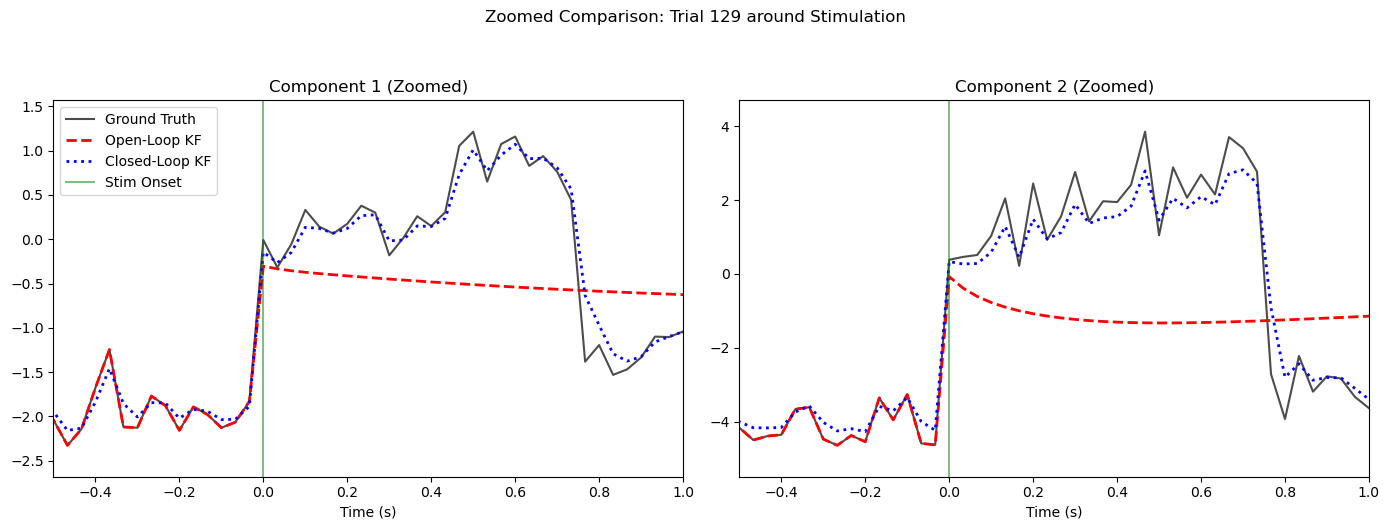

In [32]:
# Specific Zoomed-In Plot for Trial 129 (Components 1 & 2)
# ---------------------------------------------------------
target_trial_idx = 129

if target_trial_idx >= len(Z_all):
    print(f"Trial {target_trial_idx} is out of bounds (max {len(Z_all)-1}).")
else:
    z_true = Z_all[target_trial_idx]
    u_tr = U_all[target_trial_idx]

    # KF Prediction (Primed Open-Loop) - Logic from previous cells
    z_pred = np.zeros_like(z_true)
    z_pred[:stim_idx_start] = z_true[:stim_idx_start]
    
    start_t = stim_idx_start if stim_idx_start > 0 else 1
    if start_t == 1: z_pred[0] = z_true[0]

    for t in range(start_t, T):
        z_pred[t] = A_est @ z_pred[t-1] + B_est @ u_tr[t]

    # Closed-Loop KF (Traditional)
    from numpy.linalg import inv
    
    cl_tick = time.time()
    z_closed = np.zeros_like(z_true)
    z_closed[0] = z_true[0]
    P = Q_est.copy()
    I_mat = np.eye(A_est.shape[0])

    for t in range(1, T):
        # Predict
        z_pred_val = A_est @ z_closed[t-1] + B_est @ u_tr[t]
        P_pred = A_est @ P @ A_est.T + Q_est
        
        # Update
        S = P_pred + R_est
        K = P_pred @ inv(S)
        z_closed[t] = z_pred_val + K @ (z_true[t] - z_pred_val)
        P = (I_mat - K) @ P_pred
    
    cl_inference_total += (time.time() - cl_tick)

    # Naive Lag-5 Prediction (Value from 5 timesteps ago)

    # Plotting
    components_to_plot = [0, 1]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    
    # Define Zoom Window (e.g., -0.5s to +1.0s around stim)
    t_stim = time_axis[stim_idx_start]
    t_min_zoom = t_stim - 0.5
    t_max_zoom = t_stim + 1.0

    for idx, comp_i in enumerate(components_to_plot):
        ax = axes[idx]
        ax.plot(time_axis, z_true[:, comp_i], "k-", label="Ground Truth", alpha=0.7)
        ax.plot(time_axis, z_pred[:, comp_i], "r--", label="Open-Loop KF", linewidth=2)
        ax.plot(time_axis, z_closed[:, comp_i], "b:", label="Closed-Loop KF", linewidth=2)
        
        ax.axvline(time_axis[stim_idx_start], color="g", alpha=0.5, label="Stim Onset")
        
        # Apply Zoom
        ax.set_xlim([t_min_zoom, t_max_zoom])
        
        # Dynamic Y-limits for the zoomed region
        mask = (time_axis >= t_min_zoom) & (time_axis <= t_max_zoom)
        if np.any(mask):
            y_data_zoom = np.concatenate([z_true[mask, comp_i], z_pred[mask, comp_i], z_closed[mask, comp_i]])
            ymin, ymax = np.min(y_data_zoom), np.max(y_data_zoom)
            range_y = ymax - ymin if ymax != ymin else 1.0
            ax.set_ylim([ymin - 0.1*range_y, ymax + 0.1*range_y])

        ax.set_title(f"Component {comp_i + 1} (Zoomed)")
        ax.set_xlabel("Time (s)")
        if idx == 0:
            ax.legend()

    plt.suptitle(f"Zoomed Comparison: Trial {target_trial_idx} around Stimulation", y=1.05)
    plt.tight_layout()
    plt.show()

# Session 1 Analysis
We repeat the full analysis pipeline for Session 1.

In [33]:
# --- Session 1: Stats, Data Prep, dPCA ---
s_curr = sessions[1]

# 1. Stats
stats = {
    "session_id": 1,
    "mouse": s_curr.get("mouse"),
    "run_number": s_curr.get("run_number"),
    "name": s_curr.get("name"),
    "n_cells": s_curr.get("n_cells"),
    "n_trials": s_curr.get("n_trials"),
    "n_times": s_curr.get("n_times"),
    "frequency": s_curr.get("frequency"),
}
print("Session 1 stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")

outcomes = np.asarray(s_curr.get("outcome"))
values, counts = np.unique(outcomes, return_counts=True)
print("Outcome counts:")
for value, count in zip(values, counts):
    print(f"  {value}: {count}")

# 2. Data Preparation
start_time = time.time()
neural_data = s_curr['behaviour_trials']
trial_subsets = s_curr['trial_subsets']
n_trials = s_curr['n_trials']

split_idx = int(0.8 * n_trials)
train_indices = np.arange(split_idx)
test_indices = np.arange(split_idx, n_trials)
print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")

unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices) 
                         for cond in unique_conditions}
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s_curr['n_cells'], s_curr['n_times']
S = len(unique_conditions)

trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    selected_trials = trials_per_cond_train[cond][:min_trials_train]
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]
print(f"dPCA Data Prepared. Shape: {trialR.shape}")

# 3. Fit dPCA
t0 = time.time()
dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)
print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

Session 1 stats:
  session_id: 1
  mouse: J064
  run_number: 11
  name: Mouse J064, run 11
  n_cells: 788
  n_trials: 166
  n_times: 420
  frequency: 30.0
Outcome counts:
  arm: 3
  cr: 31
  fp: 13
  hit: 91
  miss: 28
Data Split: 132 Training trials, 34 Test trials
dPCA Data Prepared. Shape: (4, 788, 8, 420)
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial

## Shuffle test (Session 1)

Running 100 shuffles for Session 1...
Shuffle Test Time: 19.7664s


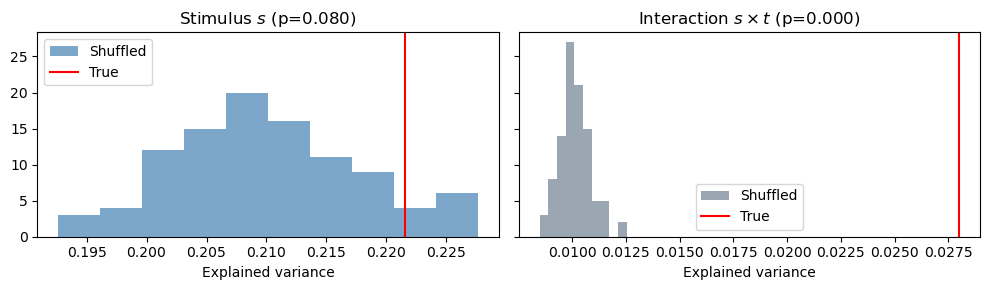

In [34]:
t0 = time.time()

n_shuffles = 100
shuffled_vars_s = []
shuffled_vars_st = []
true_var_s = np.sum(dpca.explained_variance_ratio_.get('s', np.array([0.0])))
true_var_st = np.sum(dpca.explained_variance_ratio_.get('st', np.array([0.0])))

trials_flat = trialR.reshape(-1, N, T)
labels_flat = np.repeat(np.arange(S), min_trials_train)

print(f"Running {n_shuffles} shuffles for Session 1...")
for _ in range(n_shuffles):
    shuffled_labels = np.random.permutation(labels_flat)

    R_shuff = np.zeros((N, S, T))
    for s in range(S):
        idxs = np.where(shuffled_labels == s)[0]
        R_shuff[:, s, :] = np.mean(trials_flat[idxs], axis=0)

    R_shuff_centered = R_shuff - np.mean(R_shuff.reshape((N, -1)), axis=1)[:, None, None]

    dpca_shuff = dPCA.dPCA(labels='st', regularizer=dpca.regularizer, n_components=10)
    dpca_shuff.protect = ['t']
    dpca_shuff.fit_transform(R_shuff_centered, trialR)

    shuffled_vars_s.append(np.sum(dpca_shuff.explained_variance_ratio_.get('s', np.array([0.0]))))
    shuffled_vars_st.append(np.sum(dpca_shuff.explained_variance_ratio_.get('st', np.array([0.0]))))

p_val_s = np.mean(np.array(shuffled_vars_s) >= true_var_s)
p_val_st = np.mean(np.array(shuffled_vars_st) >= true_var_st)
print(f"Shuffle Test Time: {time.time() - t0:.4f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(shuffled_vars_s, color="steelblue", alpha=0.7, label="Shuffled")
axes[0].axvline(true_var_s, color="r", label="True")
axes[0].set_title(f"Stimulus $s$ (p={p_val_s:.3f})")
axes[0].set_xlabel("Explained variance")
axes[0].legend()

axes[1].hist(shuffled_vars_st, color="slategray", alpha=0.7, label="Shuffled")
axes[1].axvline(true_var_st, color="r", label="True")
axes[1].set_title(f"Interaction $s\\times t$ (p={p_val_st:.3f})")
axes[1].set_xlabel("Explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

## Kalman Training (Session 1)

In [35]:
from sklearn.linear_model import Ridge

train_start = time.time()
time_axis = s_curr["filter_ps_time"]

all_components = []
for key in dpca.P.keys():
    for i in range(dpca.P[key].shape[1]):
        var = dpca.explained_variance_ratio_[key][i]
        all_components.append({
            "var": var,
            "key": key,
            "P": dpca.P[key][:, i],
            "D": dpca.D[key][:, i],
        })

all_components.sort(key=lambda x: x["var"], reverse=True)
top_k = 10
P_matrix = np.array([c["P"] for c in all_components[:top_k]]).T
D_matrix = np.array([c["D"] for c in all_components[:top_k]]).T

X_all = neural_data.transpose(1, 2, 0)
X_mean = np.mean(neural_data[:, train_indices, :], axis=(1, 2))
X_centered = X_all - X_mean[None, None, :]
Z_all = X_centered @ P_matrix

stim_idx_start = np.argmin(np.abs(time_axis - 0))
U_all = np.zeros((n_trials, T, 1))
U_all[:, stim_idx_start, 0] = trial_subsets

X_reg = []
Y_reg = []
for tr in train_indices:
    z_b = Z_all[tr, :-1, :]
    u_b = U_all[tr, 1:, :]
    z_f = Z_all[tr, 1:, :]
    X_reg.append(np.hstack([z_b, u_b]))
    Y_reg.append(z_f)

X_reg = np.vstack(X_reg)
Y_reg = np.vstack(Y_reg)

reg = Ridge(alpha=1e-5, fit_intercept=False)
reg.fit(X_reg, Y_reg)

AB_matrix = reg.coef_
A_est = AB_matrix[:, :10]
B_est = AB_matrix[:, 10:]

# Estimate Q (Process Noise Covariance) from training residuals
Y_pred_train = reg.predict(X_reg)
residuals = Y_reg - Y_pred_train
Q_est = np.cov(residuals, rowvar=False)

# Estimate R (Observation Noise Covariance)
R_est = Q_est.copy()

train_time = time.time() - train_start
print("Transition Matrix A shape:", A_est.shape)
print("Control Matrix B shape:", B_est.shape)
print("Q_est shape:", Q_est.shape)
print(f"Kalman training time: {train_time:.4f}s")

Transition Matrix A shape: (10, 10)
Control Matrix B shape: (10, 1)
Q_est shape: (10, 10)
Kalman training time: 0.1651s


## Kalman Inference (Session 1)

Evaluating on 24 stimulated test trials (out of 34 total test trials).
Non-stim test trials: 10
Kalman inference time: 0.1768s
Inference time per trial: 0.007365s
Closed-Loop (Traditional) time per time-step: 0.00001008s
--------------------------------------------------
GLOBAL METRICS (Session 1 | Stim Trials)
Window: Stim Onset to Stim + 5
--------------------------------------------------
Global Open-Loop MSE:   12.2248
Global Closed-Loop MSE: 0.7414
Global Naive MSE:       18.4567
Global Open-Loop R2:    -0.5682
Global Closed-Loop R2:  0.9049
Global Naive R2:        -1.3676
--------------------------------------------------
Window: Stim Onset to End
--------------------------------------------------
Global Open-Loop MSE:   5.8301
Global Closed-Loop MSE: 0.0836
Global Naive MSE:       1.7545
Global Open-Loop R2:    0.0608
Global Closed-Loop R2:  0.9865
Global Naive R2:        0.7174


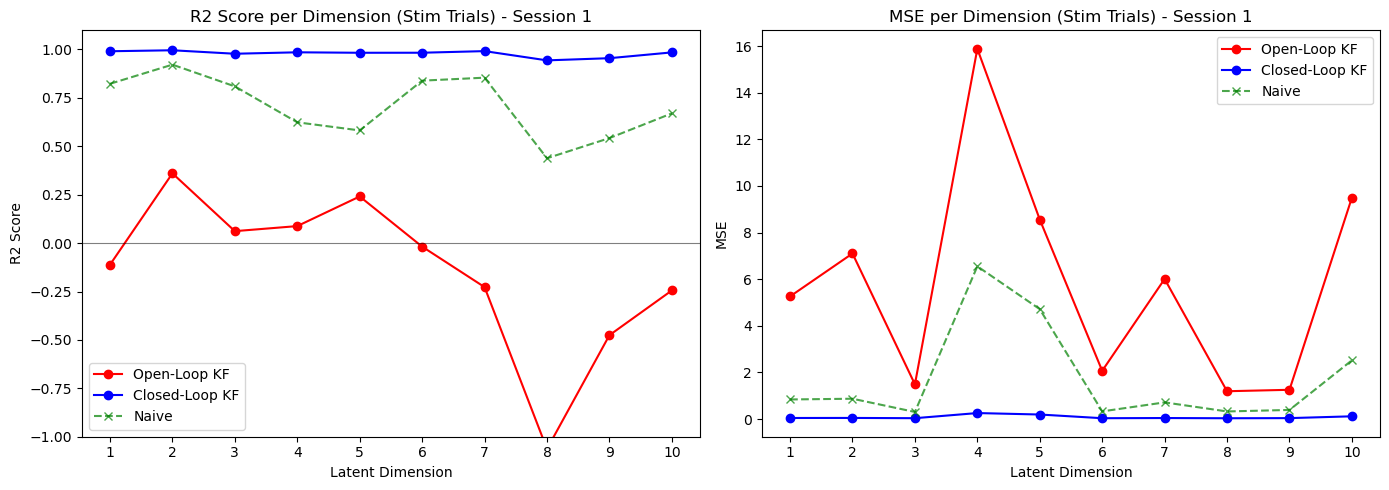

In [36]:
inference_start = time.time()

mse_scores = []
r2_scores = []
mse_naive = []
r2_naive = []
mse_closed = []
r2_closed = []

cl_inference_total = 0.0

y_true_stim_list = []
y_pred_stim_list = []
y_closed_stim_list = []
y_naive_stim_list = []

mse_scores_ns = []
r2_scores_ns = []
mse_naive_ns = []
r2_naive_ns = []
mse_closed_ns = []
r2_closed_ns = []

y_true_ns_list = []
y_pred_ns_list = []
y_closed_ns_list = []
y_naive_ns_list = []

y_true_stim_short = []
y_pred_stim_short = []
y_closed_stim_short = []
y_naive_stim_short = []

y_true_ns_short = []
y_pred_ns_short = []
y_closed_ns_short = []
y_naive_ns_short = []

stim_test_indices = [tr for tr in test_indices if trial_subsets[tr] > 0]
nonstim_test_indices = [tr for tr in test_indices if trial_subsets[tr] == 0]
print(f"Evaluating on {len(stim_test_indices)} stimulated test trials (out of {len(test_indices)} total test trials).")
print(f"Non-stim test trials: {len(nonstim_test_indices)}")

stim_idx_start = np.argmin(np.abs(time_axis - 0))
eval_window_start = stim_idx_start
eval_window_end = T

naive_lag = 5

for tr in test_indices:
    z_true = Z_all[tr]
    u_tr = U_all[tr]

    # KF Prediction (Primed Open-Loop)
    z_pred = np.zeros_like(z_true)
    z_pred[:stim_idx_start] = z_true[:stim_idx_start]
    
    start_t = stim_idx_start if stim_idx_start > 0 else 1
    if start_t == 1: z_pred[0] = z_true[0]

    for t in range(start_t, T):
        z_pred[t] = A_est @ z_pred[t-1] + B_est @ u_tr[t]

    # KF Prediction (Traditional Closed-Loop)
    from numpy.linalg import inv
    
    cl_tick = time.time()
    z_closed = np.zeros_like(z_true)
    z_closed[0] = z_true[0]
    P = Q_est.copy() 
    I_mat = np.eye(A_est.shape[0])

    for t in range(1, T):
        # Predict
        z_pred_step = A_est @ z_closed[t-1] + B_est @ u_tr[t]
        P_pred = A_est @ P @ A_est.T + Q_est
        
        # Update
        S = P_pred + R_est
        K = P_pred @ inv(S)
        
        innovation = z_true[t] - z_pred_step
        z_closed[t] = z_pred_step + K @ innovation
        P = (I_mat - K) @ P_pred
    
    cl_inference_total += (time.time() - cl_tick)

    # Naive Lag-5 Prediction
    z_naive = np.empty_like(z_true)
    z_naive[:naive_lag] = z_true[0]
    z_naive[naive_lag:] = z_true[:-naive_lag]

    y_true_win = z_true[eval_window_start:eval_window_end, :]
    y_pred_win = z_pred[eval_window_start:eval_window_end, :]
    y_closed_win = z_closed[eval_window_start:eval_window_end, :]
    y_naive_win = z_naive[eval_window_start:eval_window_end, :]

    short_end = builtins.min(T, eval_window_start + 5)
    y_true_s = z_true[eval_window_start:short_end, :]
    y_pred_s = z_pred[eval_window_start:short_end, :]
    y_closed_s = z_closed[eval_window_start:short_end, :]
    y_naive_s = z_naive[eval_window_start:short_end, :]

    if trial_subsets[tr] > 0:
        mse_scores.append(mean_squared_error(y_true_win, y_pred_win))
        r2_scores.append(r2_score(y_true_win, y_pred_win))
        mse_closed.append(mean_squared_error(y_true_win, y_closed_win))
        r2_closed.append(r2_score(y_true_win, y_closed_win))
        mse_naive.append(mean_squared_error(y_true_win, y_naive_win))
        r2_naive.append(r2_score(y_true_win, y_naive_win))
        
        y_true_stim_list.append(y_true_win)
        y_pred_stim_list.append(y_pred_win)
        y_closed_stim_list.append(y_closed_win)
        y_naive_stim_list.append(y_naive_win)

        y_true_stim_short.append(y_true_s)
        y_pred_stim_short.append(y_pred_s)
        y_closed_stim_short.append(y_closed_s)
        y_naive_stim_short.append(y_naive_s)
    else:
        mse_scores_ns.append(mean_squared_error(y_true_win, y_pred_win))
        r2_scores_ns.append(r2_score(y_true_win, y_pred_win))
        mse_closed_ns.append(mean_squared_error(y_true_win, y_closed_win))
        r2_closed_ns.append(r2_score(y_true_win, y_closed_win))
        mse_naive_ns.append(mean_squared_error(y_true_win, y_naive_win))
        r2_naive_ns.append(r2_score(y_true_win, y_naive_win))

        y_true_ns_list.append(y_true_win)
        y_pred_ns_list.append(y_pred_win)
        y_closed_ns_list.append(y_closed_win)
        y_naive_ns_list.append(y_naive_win)
        
        y_true_ns_short.append(y_true_s)
        y_pred_ns_short.append(y_pred_s)
        y_closed_ns_short.append(y_closed_s)
        y_naive_ns_short.append(y_naive_s)

inference_time = time.time() - inference_start
per_trial_time = (inference_time / len(stim_test_indices)) if stim_test_indices else float("nan")

# Calculate average inference time per time-step for Closed-Loop
total_cl_steps = len(test_indices) * (T - 1)
cl_per_step = cl_inference_total / total_cl_steps if total_cl_steps > 0 else 0.0

print(f"Kalman inference time: {inference_time:.4f}s")
print(f"Inference time per trial: {per_trial_time:.6f}s")
print(f"Closed-Loop (Traditional) time per time-step: {cl_per_step:.8f}s")


# Calculate Global Scores
if y_true_stim_list:
    Y_true_stim = np.vstack(y_true_stim_list)
    Y_pred_stim = np.vstack(y_pred_stim_list)
    Y_closed_stim = np.vstack(y_closed_stim_list)
    Y_naive_stim = np.vstack(y_naive_stim_list)
    
    Y_true_stim_s = np.vstack(y_true_stim_short)
    Y_pred_stim_s = np.vstack(y_pred_stim_short)
    Y_closed_stim_s = np.vstack(y_closed_stim_short)
    Y_naive_stim_s = np.vstack(y_naive_stim_short)

    gl_r2_open_s = r2_score(Y_true_stim_s, Y_pred_stim_s, multioutput='variance_weighted')
    gl_r2_closed_s = r2_score(Y_true_stim_s, Y_closed_stim_s, multioutput='variance_weighted')
    gl_r2_naive_s = r2_score(Y_true_stim_s, Y_naive_stim_s, multioutput='variance_weighted')
    
    gl_mse_open_s = mean_squared_error(Y_true_stim_s, Y_pred_stim_s)
    gl_mse_closed_s = mean_squared_error(Y_true_stim_s, Y_closed_stim_s)
    gl_mse_naive_s = mean_squared_error(Y_true_stim_s, Y_naive_stim_s)

    print("-" * 50)
    print("GLOBAL METRICS (Session 1 | Stim Trials)")
    print("Window: Stim Onset to Stim + 5")
    print("-" * 50)
    print(f"Global Open-Loop MSE:   {gl_mse_open_s:.4f}")
    print(f"Global Closed-Loop MSE: {gl_mse_closed_s:.4f}")
    print(f"Global Naive MSE:       {gl_mse_naive_s:.4f}")
    print(f"Global Open-Loop R2:    {gl_r2_open_s:.4f}")
    print(f"Global Closed-Loop R2:  {gl_r2_closed_s:.4f}")
    print(f"Global Naive R2:        {gl_r2_naive_s:.4f}")

    gl_r2_open = r2_score(Y_true_stim, Y_pred_stim, multioutput='variance_weighted')
    gl_r2_closed = r2_score(Y_true_stim, Y_closed_stim, multioutput='variance_weighted')
    gl_r2_naive = r2_score(Y_true_stim, Y_naive_stim, multioutput='variance_weighted')
    
    r2_open_per_dim = r2_score(Y_true_stim, Y_pred_stim, multioutput='raw_values')
    r2_closed_per_dim = r2_score(Y_true_stim, Y_closed_stim, multioutput='raw_values')
    r2_naive_per_dim = r2_score(Y_true_stim, Y_naive_stim, multioutput='raw_values')
    
    mse_open_per_dim = mean_squared_error(Y_true_stim, Y_pred_stim, multioutput='raw_values')
    mse_closed_per_dim = mean_squared_error(Y_true_stim, Y_closed_stim, multioutput='raw_values')
    mse_naive_per_dim = mean_squared_error(Y_true_stim, Y_naive_stim, multioutput='raw_values')

    gl_mse_open = np.mean(mse_open_per_dim)
    gl_mse_closed = np.mean(mse_closed_per_dim)
    gl_mse_naive = np.mean(mse_naive_per_dim)
    
    print("-" * 50)
    print("Window: Stim Onset to End")
    print("-" * 50)
    print(f"Global Open-Loop MSE:   {gl_mse_open:.4f}")
    print(f"Global Closed-Loop MSE: {gl_mse_closed:.4f}")
    print(f"Global Naive MSE:       {gl_mse_naive:.4f}")
    print(f"Global Open-Loop R2:    {gl_r2_open:.4f}")
    print(f"Global Closed-Loop R2:  {gl_r2_closed:.4f}")
    print(f"Global Naive R2:        {gl_r2_naive:.4f}")
    
    dims = np.arange(1, len(r2_open_per_dim) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(dims, r2_open_per_dim, 'r-o', label='Open-Loop KF')
    axes[0].plot(dims, r2_closed_per_dim, 'b-o', label='Closed-Loop KF')
    axes[0].plot(dims, r2_naive_per_dim, 'g--x', label='Naive', alpha=0.7)
    axes[0].axhline(0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)
    axes[0].set_xlabel('Latent Dimension')
    axes[0].set_ylabel('R2 Score')
    axes[0].set_title('R2 Score per Dimension (Stim Trials) - Session 1')
    axes[0].set_xticks(dims)
    axes[0].legend()
    axes[0].set_ylim(bottom=builtins.max(-1.0, float(np.min([r2_naive_per_dim.min(), r2_open_per_dim.min()]) - 0.1))) 
    
    axes[1].plot(dims, mse_open_per_dim, 'r-o', label='Open-Loop KF')
    axes[1].plot(dims, mse_closed_per_dim, 'b-o', label='Closed-Loop KF')
    axes[1].plot(dims, mse_naive_per_dim, 'g--x', label='Naive', alpha=0.7)
    axes[1].set_xlabel('Latent Dimension')
    axes[1].set_ylabel('MSE')
    axes[1].set_title('MSE per Dimension (Stim Trials) - Session 1')
    axes[1].set_xticks(dims)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## Representative trial overlay (Session 1)

In [ ]:
rep_candidates = list(test_indices)
rep_options = [
    (f"trial {int(tr)} | stim={int(trial_subsets[tr])}", int(tr))
    for tr in rep_candidates
 ]
rep_default = int(rep_candidates[0]) if rep_candidates else None
rep_dropdown = widgets.Dropdown(
    options=rep_options,
    value=rep_default,
    description="Trial:",
    disabled=False,
)

def plot_representative_trial_s1(trial_idx):
    if trial_idx is None:
        print("No test trials available for representative plot.")
        return

    z_true = Z_all[trial_idx]
    u_tr = U_all[trial_idx]

    z_pred = np.zeros_like(z_true)
    z_pred[:stim_idx_start] = z_true[:stim_idx_start]
    
    start_t = stim_idx_start if stim_idx_start > 0 else 1
    if start_t == 1: z_pred[0] = z_true[0]

    for t in range(start_t, T):
        z_pred[t] = A_est @ z_pred[t - 1] + B_est @ u_tr[t]

    from numpy.linalg import inv
    z_closed = np.zeros_like(z_true)
    z_closed[0] = z_true[0]
    P = Q_est.copy()
    I_mat = np.eye(A_est.shape[0])

    for t in range(1, T):
        z_pred_val = A_est @ z_closed[t-1] + B_est @ u_tr[t]
        P_pred = A_est @ P @ A_est.T + Q_est
        S = P_pred + R_est
        K = P_pred @ inv(S)
        z_closed[t] = z_pred_val + K @ (z_true[t] - z_pred_val)
        P = (I_mat - K) @ P_pred

    n_dims = builtins.min(10, z_true.shape[1])
    fig, axes = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
    axes = axes.flatten()
    for i in range(n_dims):
        ax = axes[i]
        ax.plot(time_axis, z_true[:, i], "k-", label="Ground truth" if i == 0 else None, alpha=0.7)
        ax.plot(time_axis, z_pred[:, i], "r--", label="Open-Loop KF" if i == 0 else None, linewidth=2)
        ax.plot(time_axis, z_closed[:, i], "b:", label="Closed-Loop KF" if i == 0 else None, linewidth=2)
        ax.axvline(time_axis[stim_idx_start], color="g", alpha=0.4, label="Stim" if i == 0 else None)
        ax.set_title(f"Component {i + 1}")
        if i == 0:
            ax.legend(loc="upper right")

    for j in range(n_dims, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"S1 Representative Trial {trial_idx}", y=1.02)
    plt.tight_layout()
    plt.show()

display(rep_dropdown)
widgets.interact(plot_representative_trial_s1, trial_idx=rep_dropdown)

Dropdown(description='Trial:', options=(('trial 250 | stim=0', 250), ('trial 251 | stim=150', 251), ('trial 25…

interactive(children=(Dropdown(description='Trial:', options=(('trial 250 | stim=0', 250), ('trial 251 | stim=…

<function __main__.plot_representative_trial_s1(trial_idx)>

Dropdown(description='Trial:', options=(('trial 250 | stim=0', 250), ('trial 251 | stim=150', 251), ('trial 25…

interactive(children=(Dropdown(description='Trial:', options=(('trial 250 | stim=0', 250), ('trial 251 | stim=…

<function __main__.plot_representative_trial_s1(trial_idx)>

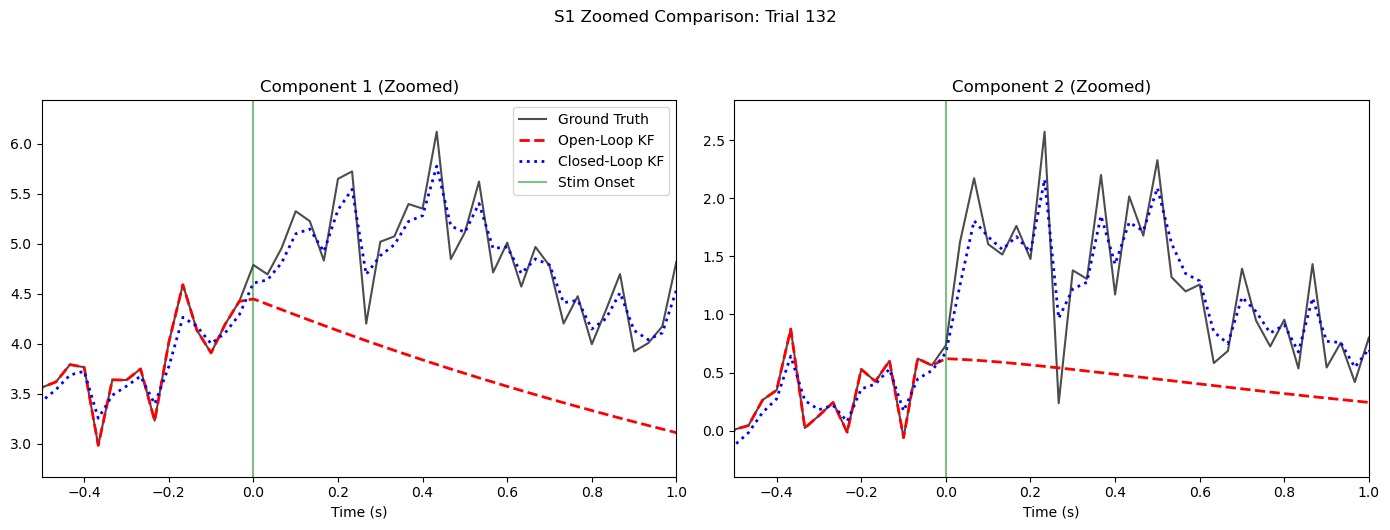

In [38]:
# Zoomed Plot S1
if stim_test_indices:
    target_trial_idx = stim_test_indices[0] # Pick first active stim trial
else:
    target_trial_idx = test_indices[0]

z_true = Z_all[target_trial_idx]
u_tr = U_all[target_trial_idx]

z_pred = np.zeros_like(z_true)
z_pred[:stim_idx_start] = z_true[:stim_idx_start]
start_t = stim_idx_start if stim_idx_start > 0 else 1
if start_t == 1: z_pred[0] = z_true[0]

for t in range(start_t, T):
    z_pred[t] = A_est @ z_pred[t-1] + B_est @ u_tr[t]

from numpy.linalg import inv
z_closed = np.zeros_like(z_true)
z_closed[0] = z_true[0]
P = Q_est.copy()
I_mat = np.eye(A_est.shape[0])

for t in range(1, T):
    z_pred_val = A_est @ z_closed[t-1] + B_est @ u_tr[t]
    P_pred = A_est @ P @ A_est.T + Q_est
    S = P_pred + R_est
    K = P_pred @ inv(S)
    z_closed[t] = z_pred_val + K @ (z_true[t] - z_pred_val)
    P = (I_mat - K) @ P_pred

components_to_plot = [0, 1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

t_stim = time_axis[stim_idx_start]
t_min_zoom = t_stim - 0.5
t_max_zoom = t_stim + 1.0

for idx, comp_i in enumerate(components_to_plot):
    ax = axes[idx]
    ax.plot(time_axis, z_true[:, comp_i], "k-", label="Ground Truth", alpha=0.7)
    ax.plot(time_axis, z_pred[:, comp_i], "r--", label="Open-Loop KF", linewidth=2)
    ax.plot(time_axis, z_closed[:, comp_i], "b:", label="Closed-Loop KF", linewidth=2)
    
    ax.axvline(time_axis[stim_idx_start], color="g", alpha=0.5, label="Stim Onset")
    
    ax.set_xlim([t_min_zoom, t_max_zoom])
    
    mask = (time_axis >= t_min_zoom) & (time_axis <= t_max_zoom)
    if np.any(mask):
        y_data_zoom = np.concatenate([z_true[mask, comp_i], z_pred[mask, comp_i], z_closed[mask, comp_i]])
        ymin, ymax = np.min(y_data_zoom), np.max(y_data_zoom)
        range_y = ymax - ymin if ymax != ymin else 1.0
        ax.set_ylim([ymin - 0.1*range_y, ymax + 0.1*range_y])

    ax.set_title(f"Component {comp_i + 1} (Zoomed)")
    ax.set_xlabel("Time (s)")
    if idx == 0:
        ax.legend()

plt.suptitle(f"S1 Zoomed Comparison: Trial {target_trial_idx}", y=1.05)
plt.tight_layout()
plt.show()

# Session 2 Analysis
We repeat the full analysis pipeline for Session 2.

In [39]:
# --- Session 2: Stats, Data Prep, dPCA ---
s_curr = sessions[2]

# 1. Stats
stats = {
    "session_id": 2,
    "mouse": s_curr.get("mouse"),
    "run_number": s_curr.get("run_number"),
    "name": s_curr.get("name"),
    "n_cells": s_curr.get("n_cells"),
    "n_trials": s_curr.get("n_trials"),
    "n_times": s_curr.get("n_times"),
    "frequency": s_curr.get("frequency"),
}
print("Session 2 stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")

outcomes = np.asarray(s_curr.get("outcome"))
values, counts = np.unique(outcomes, return_counts=True)
print("Outcome counts:")
for value, count in zip(values, counts):
    print(f"  {value}: {count}")

# 2. Data Preparation
start_time = time.time()
neural_data = s_curr['behaviour_trials']
trial_subsets = s_curr['trial_subsets']
n_trials = s_curr['n_trials']

split_idx = int(0.8 * n_trials)
train_indices = np.arange(split_idx)
test_indices = np.arange(split_idx, n_trials)
print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")

unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices) 
                         for cond in unique_conditions}
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s_curr['n_cells'], s_curr['n_times']
S = len(unique_conditions)

trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    selected_trials = trials_per_cond_train[cond][:min_trials_train]
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]
print(f"dPCA Data Prepared. Shape: {trialR.shape}")

# 3. Fit dPCA
t0 = time.time()
dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)
print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

Session 2 stats:
  session_id: 2
  mouse: J064
  run_number: 14
  name: Mouse J064, run 14
  n_cells: 919
  n_trials: 208
  n_times: 420
  frequency: 30.0
Outcome counts:
  arm: 10
  cr: 35
  fp: 25
  hit: 112
  miss: 26
Data Split: 166 Training trials, 42 Test trials
dPCA Data Prepared. Shape: (9, 919, 8, 420)
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting tri

## Shuffle test (Session 2)

Running 100 shuffles for Session 2...
Shuffle Test Time: 27.7836s


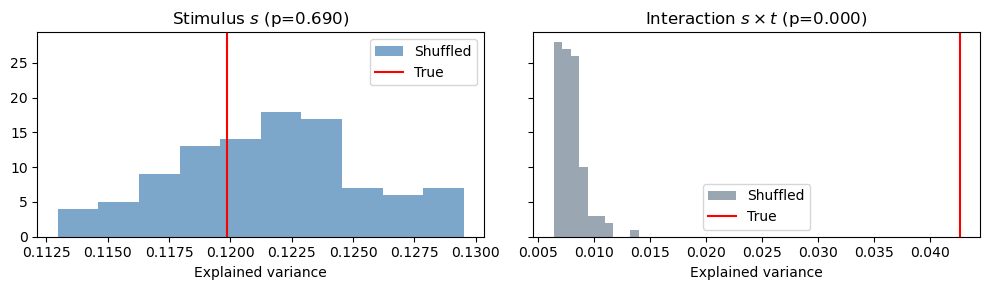

In [40]:
t0 = time.time()

n_shuffles = 100
shuffled_vars_s = []
shuffled_vars_st = []
true_var_s = np.sum(dpca.explained_variance_ratio_.get('s', np.array([0.0])))
true_var_st = np.sum(dpca.explained_variance_ratio_.get('st', np.array([0.0])))

trials_flat = trialR.reshape(-1, N, T)
labels_flat = np.repeat(np.arange(S), min_trials_train)

print(f"Running {n_shuffles} shuffles for Session 2...")
for _ in range(n_shuffles):
    shuffled_labels = np.random.permutation(labels_flat)

    R_shuff = np.zeros((N, S, T))
    for s in range(S):
        idxs = np.where(shuffled_labels == s)[0]
        R_shuff[:, s, :] = np.mean(trials_flat[idxs], axis=0)

    R_shuff_centered = R_shuff - np.mean(R_shuff.reshape((N, -1)), axis=1)[:, None, None]

    dpca_shuff = dPCA.dPCA(labels='st', regularizer=dpca.regularizer, n_components=10)
    dpca_shuff.protect = ['t']
    dpca_shuff.fit_transform(R_shuff_centered, trialR)

    shuffled_vars_s.append(np.sum(dpca_shuff.explained_variance_ratio_.get('s', np.array([0.0]))))
    shuffled_vars_st.append(np.sum(dpca_shuff.explained_variance_ratio_.get('st', np.array([0.0]))))

p_val_s = np.mean(np.array(shuffled_vars_s) >= true_var_s)
p_val_st = np.mean(np.array(shuffled_vars_st) >= true_var_st)
print(f"Shuffle Test Time: {time.time() - t0:.4f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(shuffled_vars_s, color="steelblue", alpha=0.7, label="Shuffled")
axes[0].axvline(true_var_s, color="r", label="True")
axes[0].set_title(f"Stimulus $s$ (p={p_val_s:.3f})")
axes[0].set_xlabel("Explained variance")
axes[0].legend()

axes[1].hist(shuffled_vars_st, color="slategray", alpha=0.7, label="Shuffled")
axes[1].axvline(true_var_st, color="r", label="True")
axes[1].set_title(f"Interaction $s\\times t$ (p={p_val_st:.3f})")
axes[1].set_xlabel("Explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

## Kalman Training (Session 2)

In [41]:
from sklearn.linear_model import Ridge

train_start = time.time()
time_axis = s_curr["filter_ps_time"]

all_components = []
for key in dpca.P.keys():
    for i in range(dpca.P[key].shape[1]):
        var = dpca.explained_variance_ratio_[key][i]
        all_components.append({
            "var": var,
            "key": key,
            "P": dpca.P[key][:, i],
            "D": dpca.D[key][:, i],
        })

all_components.sort(key=lambda x: x["var"], reverse=True)
top_k = 10
P_matrix = np.array([c["P"] for c in all_components[:top_k]]).T
D_matrix = np.array([c["D"] for c in all_components[:top_k]]).T

X_all = neural_data.transpose(1, 2, 0)
X_mean = np.mean(neural_data[:, train_indices, :], axis=(1, 2))
X_centered = X_all - X_mean[None, None, :]
Z_all = X_centered @ P_matrix

stim_idx_start = np.argmin(np.abs(time_axis - 0))
U_all = np.zeros((n_trials, T, 1))
U_all[:, stim_idx_start, 0] = trial_subsets

X_reg = []
Y_reg = []
for tr in train_indices:
    z_b = Z_all[tr, :-1, :]
    u_b = U_all[tr, 1:, :]
    z_f = Z_all[tr, 1:, :]
    X_reg.append(np.hstack([z_b, u_b]))
    Y_reg.append(z_f)

X_reg = np.vstack(X_reg)
Y_reg = np.vstack(Y_reg)

reg = Ridge(alpha=1e-5, fit_intercept=False)
reg.fit(X_reg, Y_reg)

AB_matrix = reg.coef_
A_est = AB_matrix[:, :10]
B_est = AB_matrix[:, 10:]

# Estimate Q (Process Noise Covariance) from training residuals
Y_pred_train = reg.predict(X_reg)
residuals = Y_reg - Y_pred_train
Q_est = np.cov(residuals, rowvar=False)

# Estimate R (Observation Noise Covariance)
R_est = Q_est.copy()

train_time = time.time() - train_start
print("Transition Matrix A shape:", A_est.shape)
print("Control Matrix B shape:", B_est.shape)
print("Q_est shape:", Q_est.shape)
print(f"Kalman training time: {train_time:.4f}s")

Transition Matrix A shape: (10, 10)
Control Matrix B shape: (10, 1)
Q_est shape: (10, 10)
Kalman training time: 0.2447s


## Kalman Inference (Session 2)

Evaluating on 28 stimulated test trials (out of 42 total test trials).
Non-stim test trials: 14
Kalman inference time: 0.2187s
Inference time per trial: 0.007810s
Closed-Loop (Traditional) time per time-step: 0.00001010s
--------------------------------------------------
GLOBAL METRICS (Session 2 | Stim Trials)
Window: Stim Onset to Stim + 5
--------------------------------------------------
Global Open-Loop MSE:   23.3776
Global Closed-Loop MSE: 1.2841
Global Naive MSE:       80.3020
Global Open-Loop R2:    -0.0783
Global Closed-Loop R2:  0.9408
Global Naive R2:        -2.7040
--------------------------------------------------
Window: Stim Onset to End
--------------------------------------------------
Global Open-Loop MSE:   7.4598
Global Closed-Loop MSE: 0.1348
Global Naive MSE:       4.5787
Global Open-Loop R2:    0.3962
Global Closed-Loop R2:  0.9891
Global Naive R2:        0.6294


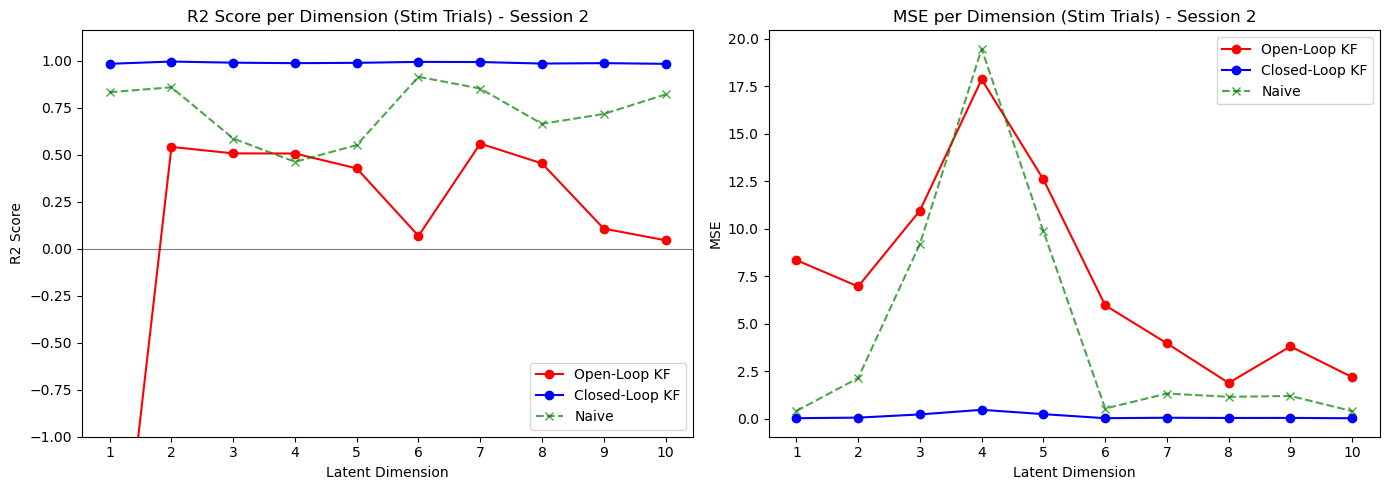

In [42]:
inference_start = time.time()

mse_scores = []
r2_scores = []
mse_naive = []
r2_naive = []
mse_closed = []
r2_closed = []

cl_inference_total = 0.0

y_true_stim_list = []
y_pred_stim_list = []
y_closed_stim_list = []
y_naive_stim_list = []

mse_scores_ns = []
r2_scores_ns = []
mse_naive_ns = []
r2_naive_ns = []
mse_closed_ns = []
r2_closed_ns = []

y_true_ns_list = []
y_pred_ns_list = []
y_closed_ns_list = []
y_naive_ns_list = []

y_true_stim_short = []
y_pred_stim_short = []
y_closed_stim_short = []
y_naive_stim_short = []

y_true_ns_short = []
y_pred_ns_short = []
y_closed_ns_short = []
y_naive_ns_short = []

stim_test_indices = [tr for tr in test_indices if trial_subsets[tr] > 0]
nonstim_test_indices = [tr for tr in test_indices if trial_subsets[tr] == 0]
print(f"Evaluating on {len(stim_test_indices)} stimulated test trials (out of {len(test_indices)} total test trials).")
print(f"Non-stim test trials: {len(nonstim_test_indices)}")

stim_idx_start = np.argmin(np.abs(time_axis - 0))
eval_window_start = stim_idx_start
eval_window_end = T

naive_lag = 5

for tr in test_indices:
    z_true = Z_all[tr]
    u_tr = U_all[tr]

    z_pred = np.zeros_like(z_true)
    z_pred[:stim_idx_start] = z_true[:stim_idx_start]
    
    start_t = stim_idx_start if stim_idx_start > 0 else 1
    if start_t == 1: z_pred[0] = z_true[0]

    for t in range(start_t, T):
        z_pred[t] = A_est @ z_pred[t-1] + B_est @ u_tr[t]

    from numpy.linalg import inv
    
    cl_tick = time.time()
    z_closed = np.zeros_like(z_true)
    z_closed[0] = z_true[0]
    P = Q_est.copy() 
    I_mat = np.eye(A_est.shape[0])

    for t in range(1, T):
        z_pred_step = A_est @ z_closed[t-1] + B_est @ u_tr[t]
        P_pred = A_est @ P @ A_est.T + Q_est
        
        S = P_pred + R_est
        K = P_pred @ inv(S)
        
        innovation = z_true[t] - z_pred_step
        z_closed[t] = z_pred_step + K @ innovation
        P = (I_mat - K) @ P_pred
    
    cl_inference_total += (time.time() - cl_tick)

    z_naive = np.empty_like(z_true)
    z_naive[:naive_lag] = z_true[0]
    z_naive[naive_lag:] = z_true[:-naive_lag]

    y_true_win = z_true[eval_window_start:eval_window_end, :]
    y_pred_win = z_pred[eval_window_start:eval_window_end, :]
    y_closed_win = z_closed[eval_window_start:eval_window_end, :]
    y_naive_win = z_naive[eval_window_start:eval_window_end, :]

    short_end = builtins.min(T, eval_window_start + 5)
    y_true_s = z_true[eval_window_start:short_end, :]
    y_pred_s = z_pred[eval_window_start:short_end, :]
    y_closed_s = z_closed[eval_window_start:short_end, :]
    y_naive_s = z_naive[eval_window_start:short_end, :]

    if trial_subsets[tr] > 0:
        mse_scores.append(mean_squared_error(y_true_win, y_pred_win))
        r2_scores.append(r2_score(y_true_win, y_pred_win))
        mse_closed.append(mean_squared_error(y_true_win, y_closed_win))
        r2_closed.append(r2_score(y_true_win, y_closed_win))
        mse_naive.append(mean_squared_error(y_true_win, y_naive_win))
        r2_naive.append(r2_score(y_true_win, y_naive_win))
        
        y_true_stim_list.append(y_true_win)
        y_pred_stim_list.append(y_pred_win)
        y_closed_stim_list.append(y_closed_win)
        y_naive_stim_list.append(y_naive_win)

        y_true_stim_short.append(y_true_s)
        y_pred_stim_short.append(y_pred_s)
        y_closed_stim_short.append(y_closed_s)
        y_naive_stim_short.append(y_naive_s)
    else:
        mse_scores_ns.append(mean_squared_error(y_true_win, y_pred_win))
        r2_scores_ns.append(r2_score(y_true_win, y_pred_win))
        mse_closed_ns.append(mean_squared_error(y_true_win, y_closed_win))
        r2_closed_ns.append(r2_score(y_true_win, y_closed_win))
        mse_naive_ns.append(mean_squared_error(y_true_win, y_naive_win))
        r2_naive_ns.append(r2_score(y_true_win, y_naive_win))

        y_true_ns_list.append(y_true_win)
        y_pred_ns_list.append(y_pred_win)
        y_closed_ns_list.append(y_closed_win)
        y_naive_ns_list.append(y_naive_win)
        
        y_true_ns_short.append(y_true_s)
        y_pred_ns_short.append(y_pred_s)
        y_closed_ns_short.append(y_closed_s)
        y_naive_ns_short.append(y_naive_s)

inference_time = time.time() - inference_start
per_trial_time = (inference_time / len(stim_test_indices)) if stim_test_indices else float("nan")

# Calculate average inference time per time-step for Closed-Loop
total_cl_steps = len(test_indices) * (T - 1)
cl_per_step = cl_inference_total / total_cl_steps if total_cl_steps > 0 else 0.0

print(f"Kalman inference time: {inference_time:.4f}s")
print(f"Inference time per trial: {per_trial_time:.6f}s")
print(f"Closed-Loop (Traditional) time per time-step: {cl_per_step:.8f}s")

# Calculate Global Scores
if y_true_stim_list:
    Y_true_stim = np.vstack(y_true_stim_list)
    Y_pred_stim = np.vstack(y_pred_stim_list)
    Y_closed_stim = np.vstack(y_closed_stim_list)
    Y_naive_stim = np.vstack(y_naive_stim_list)
    
    Y_true_stim_s = np.vstack(y_true_stim_short)
    Y_pred_stim_s = np.vstack(y_pred_stim_short)
    Y_closed_stim_s = np.vstack(y_closed_stim_short)
    Y_naive_stim_s = np.vstack(y_naive_stim_short)

    gl_r2_open_s = r2_score(Y_true_stim_s, Y_pred_stim_s, multioutput='variance_weighted')
    gl_r2_closed_s = r2_score(Y_true_stim_s, Y_closed_stim_s, multioutput='variance_weighted')
    gl_r2_naive_s = r2_score(Y_true_stim_s, Y_naive_stim_s, multioutput='variance_weighted')
    
    gl_mse_open_s = mean_squared_error(Y_true_stim_s, Y_pred_stim_s)
    gl_mse_closed_s = mean_squared_error(Y_true_stim_s, Y_closed_stim_s)
    gl_mse_naive_s = mean_squared_error(Y_true_stim_s, Y_naive_stim_s)

    print("-" * 50)
    print("GLOBAL METRICS (Session 2 | Stim Trials)")
    print("Window: Stim Onset to Stim + 5")
    print("-" * 50)
    print(f"Global Open-Loop MSE:   {gl_mse_open_s:.4f}")
    print(f"Global Closed-Loop MSE: {gl_mse_closed_s:.4f}")
    print(f"Global Naive MSE:       {gl_mse_naive_s:.4f}")
    print(f"Global Open-Loop R2:    {gl_r2_open_s:.4f}")
    print(f"Global Closed-Loop R2:  {gl_r2_closed_s:.4f}")
    print(f"Global Naive R2:        {gl_r2_naive_s:.4f}")

    gl_r2_open = r2_score(Y_true_stim, Y_pred_stim, multioutput='variance_weighted')
    gl_r2_closed = r2_score(Y_true_stim, Y_closed_stim, multioutput='variance_weighted')
    gl_r2_naive = r2_score(Y_true_stim, Y_naive_stim, multioutput='variance_weighted')
    
    r2_open_per_dim = r2_score(Y_true_stim, Y_pred_stim, multioutput='raw_values')
    r2_closed_per_dim = r2_score(Y_true_stim, Y_closed_stim, multioutput='raw_values')
    r2_naive_per_dim = r2_score(Y_true_stim, Y_naive_stim, multioutput='raw_values')
    
    mse_open_per_dim = mean_squared_error(Y_true_stim, Y_pred_stim, multioutput='raw_values')
    mse_closed_per_dim = mean_squared_error(Y_true_stim, Y_closed_stim, multioutput='raw_values')
    mse_naive_per_dim = mean_squared_error(Y_true_stim, Y_naive_stim, multioutput='raw_values')

    gl_mse_open = np.mean(mse_open_per_dim)
    gl_mse_closed = np.mean(mse_closed_per_dim)
    gl_mse_naive = np.mean(mse_naive_per_dim)
    
    print("-" * 50)
    print("Window: Stim Onset to End")
    print("-" * 50)
    print(f"Global Open-Loop MSE:   {gl_mse_open:.4f}")
    print(f"Global Closed-Loop MSE: {gl_mse_closed:.4f}")
    print(f"Global Naive MSE:       {gl_mse_naive:.4f}")
    print(f"Global Open-Loop R2:    {gl_r2_open:.4f}")
    print(f"Global Closed-Loop R2:  {gl_r2_closed:.4f}")
    print(f"Global Naive R2:        {gl_r2_naive:.4f}")
    
    dims = np.arange(1, len(r2_open_per_dim) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(dims, r2_open_per_dim, 'r-o', label='Open-Loop KF')
    axes[0].plot(dims, r2_closed_per_dim, 'b-o', label='Closed-Loop KF')
    axes[0].plot(dims, r2_naive_per_dim, 'g--x', label='Naive', alpha=0.7)
    axes[0].axhline(0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)
    axes[0].set_xlabel('Latent Dimension')
    axes[0].set_ylabel('R2 Score')
    axes[0].set_title('R2 Score per Dimension (Stim Trials) - Session 2')
    axes[0].set_xticks(dims)
    axes[0].legend()
    axes[0].set_ylim(bottom=builtins.max(-1.0, float(np.min([r2_naive_per_dim.min(), r2_open_per_dim.min()]) - 0.1))) 
    
    axes[1].plot(dims, mse_open_per_dim, 'r-o', label='Open-Loop KF')
    axes[1].plot(dims, mse_closed_per_dim, 'b-o', label='Closed-Loop KF')
    axes[1].plot(dims, mse_naive_per_dim, 'g--x', label='Naive', alpha=0.7)
    axes[1].set_xlabel('Latent Dimension')
    axes[1].set_ylabel('MSE')
    axes[1].set_title('MSE per Dimension (Stim Trials) - Session 2')
    axes[1].set_xticks(dims)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## Representative trial overlay (Session 2)

In [43]:
rep_candidates = list(test_indices)
rep_options = [
    (f"trial {int(tr)} | stim={int(trial_subsets[tr])}", int(tr))
    for tr in rep_candidates
 ]
rep_default = int(rep_candidates[0]) if rep_candidates else None
rep_dropdown = widgets.Dropdown(
    options=rep_options,
    value=rep_default,
    description="Trial:",
    disabled=False,
)

def plot_representative_trial_s2(trial_idx):
    if trial_idx is None:
        print("No test trials available for representative plot.")
        return

    z_true = Z_all[trial_idx]
    u_tr = U_all[trial_idx]

    z_pred = np.zeros_like(z_true)
    z_pred[:stim_idx_start] = z_true[:stim_idx_start]
    
    start_t = stim_idx_start if stim_idx_start > 0 else 1
    if start_t == 1: z_pred[0] = z_true[0]

    for t in range(start_t, T):
        z_pred[t] = A_est @ z_pred[t - 1] + B_est @ u_tr[t]

    from numpy.linalg import inv
    z_closed = np.zeros_like(z_true)
    z_closed[0] = z_true[0]
    P = Q_est.copy()
    I_mat = np.eye(A_est.shape[0])

    for t in range(1, T):
        z_pred_val = A_est @ z_closed[t-1] + B_est @ u_tr[t]
        P_pred = A_est @ P @ A_est.T + Q_est
        S = P_pred + R_est
        K = P_pred @ inv(S)
        z_closed[t] = z_pred_val + K @ (z_true[t] - z_pred_val)
        P = (I_mat - K) @ P_pred

    n_dims = builtins.min(10, z_true.shape[1])
    fig, axes = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
    axes = axes.flatten()
    for i in range(n_dims):
        ax = axes[i]
        ax.plot(time_axis, z_true[:, i], "k-", label="Ground truth" if i == 0 else None, alpha=0.7)
        ax.plot(time_axis, z_pred[:, i], "r--", label="Open-Loop KF" if i == 0 else None, linewidth=2)
        ax.plot(time_axis, z_closed[:, i], "b:", label="Closed-Loop KF" if i == 0 else None, linewidth=2)
        ax.axvline(time_axis[stim_idx_start], color="g", alpha=0.4, label="Stim" if i == 0 else None)
        ax.set_title(f"Component {i + 1}")
        if i == 0:
            ax.legend(loc="upper right")

    for j in range(n_dims, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"S2 Representative Trial {trial_idx}", y=1.02)
    plt.tight_layout()
    plt.show()

display(rep_dropdown)
widgets.interact(plot_representative_trial_s2, trial_idx=rep_dropdown)

Dropdown(description='Trial:', options=(('trial 166 | stim=150', 166), ('trial 167 | stim=0', 167), ('trial 16…

interactive(children=(Dropdown(description='Trial:', options=(('trial 166 | stim=150', 166), ('trial 167 | sti…

<function __main__.plot_representative_trial_s2(trial_idx)>

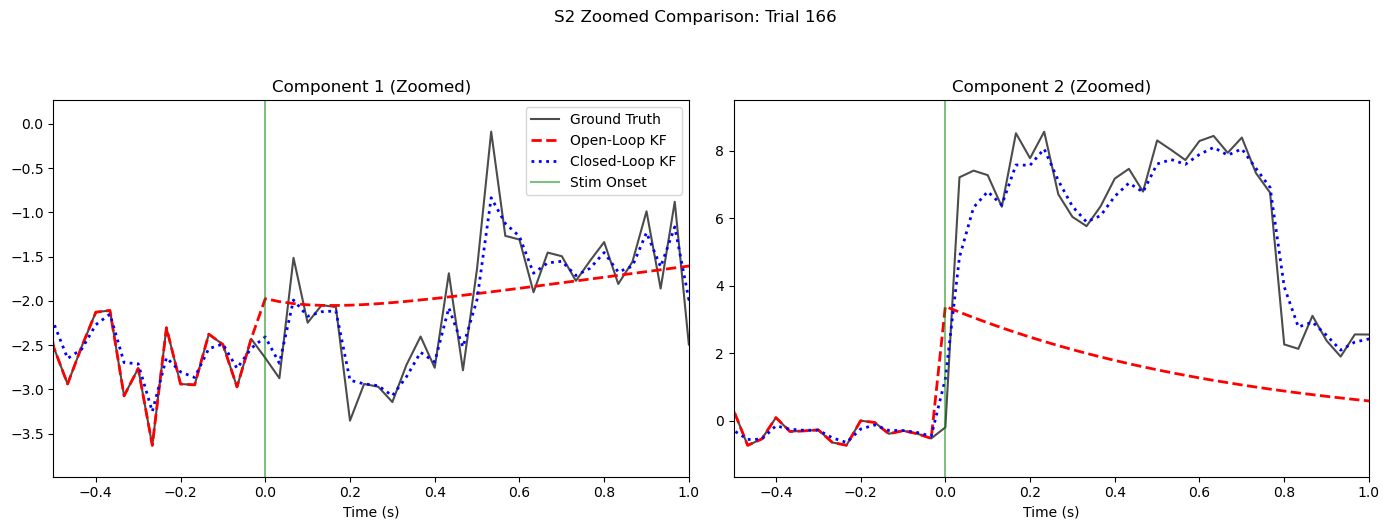

In [44]:
# Zoomed Plot S2
if stim_test_indices:
    target_trial_idx = stim_test_indices[0] # Pick first active stim trial
else:
    target_trial_idx = test_indices[0]

z_true = Z_all[target_trial_idx]
u_tr = U_all[target_trial_idx]

z_pred = np.zeros_like(z_true)
z_pred[:stim_idx_start] = z_true[:stim_idx_start]
start_t = stim_idx_start if stim_idx_start > 0 else 1
if start_t == 1: z_pred[0] = z_true[0]

for t in range(start_t, T):
    z_pred[t] = A_est @ z_pred[t-1] + B_est @ u_tr[t]

from numpy.linalg import inv
z_closed = np.zeros_like(z_true)
z_closed[0] = z_true[0]
P = Q_est.copy()
I_mat = np.eye(A_est.shape[0])

for t in range(1, T):
    z_pred_val = A_est @ z_closed[t-1] + B_est @ u_tr[t]
    P_pred = A_est @ P @ A_est.T + Q_est
    S = P_pred + R_est
    K = P_pred @ inv(S)
    z_closed[t] = z_pred_val + K @ (z_true[t] - z_pred_val)
    P = (I_mat - K) @ P_pred

components_to_plot = [0, 1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

t_stim = time_axis[stim_idx_start]
t_min_zoom = t_stim - 0.5
t_max_zoom = t_stim + 1.0

for idx, comp_i in enumerate(components_to_plot):
    ax = axes[idx]
    ax.plot(time_axis, z_true[:, comp_i], "k-", label="Ground Truth", alpha=0.7)
    ax.plot(time_axis, z_pred[:, comp_i], "r--", label="Open-Loop KF", linewidth=2)
    ax.plot(time_axis, z_closed[:, comp_i], "b:", label="Closed-Loop KF", linewidth=2)
    
    ax.axvline(time_axis[stim_idx_start], color="g", alpha=0.5, label="Stim Onset")
    
    ax.set_xlim([t_min_zoom, t_max_zoom])
    
    mask = (time_axis >= t_min_zoom) & (time_axis <= t_max_zoom)
    if np.any(mask):
        y_data_zoom = np.concatenate([z_true[mask, comp_i], z_pred[mask, comp_i], z_closed[mask, comp_i]])
        ymin, ymax = np.min(y_data_zoom), np.max(y_data_zoom)
        range_y = ymax - ymin if ymax != ymin else 1.0
        ax.set_ylim([ymin - 0.1*range_y, ymax + 0.1*range_y])

    ax.set_title(f"Component {comp_i + 1} (Zoomed)")
    ax.set_xlabel("Time (s)")
    if idx == 0:
        ax.legend()

plt.suptitle(f"S2 Zoomed Comparison: Trial {target_trial_idx}", y=1.05)
plt.tight_layout()
plt.show()

# Cross-Session Analysis (Sessions 0-9)
We now run the complete pipeline iteratively for all requested sessions (0 through 9) to gather performance statistics across the dataset. We collect metrics for:
1.  **Short Window (Stim onset + 5 timesteps)**: To evaluate immediate response prediction.
2.  **Full Window (Stim onset to end)**: To evaluate long-term trajectory tracking.
3.  **Computational Cost**: Inference time per trial and per time-step.

In [45]:
import time
import numpy as np
import builtins
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from numpy.linalg import inv
import matplotlib.pyplot as plt

# Initialize storage for metrics
session_metrics = {
    "ids": [],
    # Short Window Metrics (Stim + 5)
    "mse_open_short": [], "mse_closed_short": [], "mse_naive_short": [],
    "r2_open_short": [], "r2_closed_short": [], "r2_naive_short": [],
    # Full Window Metrics (Stim to End)
    "mse_open_full": [], "mse_closed_full": [], "mse_naive_full": [],
    "r2_open_full": [], "r2_closed_full": [], "r2_naive_full": [],
    # Timing
    "inference_time_per_trial": [],
    "cl_time_per_step": []
}

sessions_to_run = range(10)

for sid in sessions_to_run:
    if sid not in sessions:
        print(f"Session {sid} not found. Skipping.")
        continue
        
    print(f"--- Processing Session {sid} ---")
    s_curr = sessions[sid]
    
    # ---------------------------
    # 1. Data Prep
    # ---------------------------
    neural_data = s_curr['behaviour_trials']
    trial_subsets = s_curr['trial_subsets']
    n_trials = s_curr['n_trials']
    
    # Split
    split_idx = int(0.8 * n_trials)
    train_indices = np.arange(split_idx)
    test_indices = np.arange(split_idx, n_trials)
    
    # Balance for dPCA
    unique_conditions = np.unique(trial_subsets)
    trials_per_cond_train = {cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices) 
                             for cond in unique_conditions}
    min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])
    
    N, T = s_curr['n_cells'], s_curr['n_times']
    S = len(unique_conditions)
    
    if min_trials_train == 0:
        print(f"  Warning: Insufficient training trials for Session {sid}. Skipping.")
        continue

    trialR = np.zeros((min_trials_train, N, S, T))
    for s_idx, cond in enumerate(unique_conditions):
        selected_trials = trials_per_cond_train[cond][:min_trials_train]
        for i, t_idx in enumerate(selected_trials):
            trialR[i, :, s_idx, :] = neural_data[:, t_idx, :]

    R = np.mean(trialR, axis=0)
    R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]
    
    # ---------------------------
    # 2. Fit dPCA
    # ---------------------------
    # We refit dPCA for each session to get the best session-specific latent space.
    dpca_sess = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
    dpca_sess.protect = ['t']
    Z_sess = dpca_sess.fit_transform(R_centered, trialR)
    
    # ---------------------------
    # 3. Kalman Training
    # ---------------------------
    time_axis = s_curr["filter_ps_time"]
    
    # Extract components
    all_components = []
    for key in dpca_sess.P.keys():
        for i in range(dpca_sess.P[key].shape[1]):
            var = dpca_sess.explained_variance_ratio_[key][i]
            all_components.append({
                "var": var,
                "key": key,
                "P": dpca_sess.P[key][:, i],
                "D": dpca_sess.D[key][:, i],
            })
    all_components.sort(key=lambda x: x["var"], reverse=True)
    top_k = 10
    P_matrix = np.array([c["P"] for c in all_components[:top_k]]).T
    
    # Project Data
    X_all = neural_data.transpose(1, 2, 0)
    X_mean = np.mean(neural_data[:, train_indices, :], axis=(1, 2))
    X_centered = X_all - X_mean[None, None, :]
    Z_all = X_centered @ P_matrix
    
    # Build Regression Matrices
    stim_idx_start = np.argmin(np.abs(time_axis - 0))
    U_all = np.zeros((n_trials, T, 1))
    U_all[:, stim_idx_start, 0] = trial_subsets
    
    X_reg = []
    Y_reg = []
    for tr in train_indices:
        z_b = Z_all[tr, :-1, :]
        u_b = U_all[tr, 1:, :]
        z_f = Z_all[tr, 1:, :]
        X_reg.append(np.hstack([z_b, u_b]))
        Y_reg.append(z_f)
        
    X_reg = np.vstack(X_reg)
    Y_reg = np.vstack(Y_reg)
    
    reg = Ridge(alpha=1e-5, fit_intercept=False)
    reg.fit(X_reg, Y_reg)
    
    AB_matrix = reg.coef_
    A_est = AB_matrix[:, :10]
    B_est = AB_matrix[:, 10:]
    
    # Noise Estimation
    Y_pred_train = reg.predict(X_reg)
    residuals = Y_reg - Y_pred_train
    Q_est = np.cov(residuals, rowvar=False)
    R_est = Q_est.copy()
    
    # ---------------------------
    # 4. Inference & Evaluation
    # ---------------------------
    stim_test_indices = [tr for tr in test_indices if trial_subsets[tr] > 0]
    # We focus evaluation on Stimulated trials as in previous analysis
    
    y_true_stim_short = []
    y_pred_stim_short = []
    y_closed_stim_short = []
    y_naive_stim_short = []
    
    y_true_stim_full = []
    y_pred_stim_full = []
    y_closed_stim_full = []
    y_naive_stim_full = []

    cl_inference_total = 0.0
    inference_start_time = time.time()
    
    naive_lag = 5
    eval_window_start = stim_idx_start
    eval_window_end = T
    
    I_mat = np.eye(A_est.shape[0])

    for tr in stim_test_indices:
        z_true = Z_all[tr]
        u_tr = U_all[tr]
        
        # Open-Loop (Primed)
        z_pred = np.zeros_like(z_true)
        z_pred[:stim_idx_start] = z_true[:stim_idx_start]
        start_t = stim_idx_start if stim_idx_start > 0 else 1
        if start_t == 1: z_pred[0] = z_true[0]

        for t in range(start_t, T):
            z_pred[t] = A_est @ z_pred[t-1] + B_est @ u_tr[t]
            
        # Closed-Loop (Traditional)
        cl_tick = time.time()
        z_closed = np.zeros_like(z_true)
        z_closed[0] = z_true[0]
        P = Q_est.copy()
        
        for t in range(1, T):
            # Predict
            z_pred_val = A_est @ z_closed[t-1] + B_est @ u_tr[t]
            P_pred = A_est @ P @ A_est.T + Q_est
            # Update
            S = P_pred + R_est
            K = P_pred @ inv(S)
            z_closed[t] = z_pred_val + K @ (z_true[t] - z_pred_val)
            P = (I_mat - K) @ P_pred
        
        cl_inference_total += (time.time() - cl_tick)
        
        # Naive
        z_naive = np.empty_like(z_true)
        z_naive[:naive_lag] = z_true[0]
        z_naive[naive_lag:] = z_true[:-naive_lag]
        
        # Collect Windows
        # Full Window
        y_true_stim_full.append(z_true[eval_window_start:eval_window_end, :])
        y_pred_stim_full.append(z_pred[eval_window_start:eval_window_end, :])
        y_closed_stim_full.append(z_closed[eval_window_start:eval_window_end, :])
        y_naive_stim_full.append(z_naive[eval_window_start:eval_window_end, :])
        
        # Short Window
        short_end = builtins.min(T, eval_window_start + 5)
        y_true_stim_short.append(z_true[eval_window_start:short_end, :])
        y_pred_stim_short.append(z_pred[eval_window_start:short_end, :])
        y_closed_stim_short.append(z_closed[eval_window_start:short_end, :])
        y_naive_stim_short.append(z_naive[eval_window_start:short_end, :])

    total_inference_time = time.time() - inference_start_time
    
    # ---------------------------
    # 5. Metric Aggregation
    # ---------------------------
    session_metrics["ids"].append(sid)
    
    # Timing
    n_stim_tests = len(stim_test_indices)
    if n_stim_tests > 0:
        session_metrics["inference_time_per_trial"].append(total_inference_time / n_stim_tests)
        
        total_cl_steps = n_stim_tests * (T - 1)
        session_metrics["cl_time_per_step"].append(cl_inference_total / total_cl_steps if total_cl_steps > 0 else 0)
        
        # Metrics - Short Window
        Y_true_s = np.vstack(y_true_stim_short)
        Y_pred_s = np.vstack(y_pred_stim_short)
        Y_closed_s = np.vstack(y_closed_stim_short)
        Y_naive_s = np.vstack(y_naive_stim_short)
        
        session_metrics["mse_open_short"].append(mean_squared_error(Y_true_s, Y_pred_s))
        session_metrics["mse_closed_short"].append(mean_squared_error(Y_true_s, Y_closed_s))
        session_metrics["mse_naive_short"].append(mean_squared_error(Y_true_s, Y_naive_s))
        
        session_metrics["r2_open_short"].append(r2_score(Y_true_s, Y_pred_s, multioutput='variance_weighted'))
        session_metrics["r2_closed_short"].append(r2_score(Y_true_s, Y_closed_s, multioutput='variance_weighted'))
        session_metrics["r2_naive_short"].append(r2_score(Y_true_s, Y_naive_s, multioutput='variance_weighted'))

        # Metrics - Full Window
        Y_true_f = np.vstack(y_true_stim_full)
        Y_pred_f = np.vstack(y_pred_stim_full)
        Y_closed_f = np.vstack(y_closed_stim_full)
        Y_naive_f = np.vstack(y_naive_stim_full)
        
        # For full window MSE, we take mean of raw values to match previous "Average MSE across Dims" logic if preferred,
        # or just global mean_squared_error (which flattens). The previous code used np.mean(mse_..._per_dim).
        # mean_squared_error(multioutput='uniform_average') is default, which matches np.mean(per_dim).
        session_metrics["mse_open_full"].append(mean_squared_error(Y_true_f, Y_pred_f))
        session_metrics["mse_closed_full"].append(mean_squared_error(Y_true_f, Y_closed_f))
        session_metrics["mse_naive_full"].append(mean_squared_error(Y_true_f, Y_naive_f))
        
        session_metrics["r2_open_full"].append(r2_score(Y_true_f, Y_pred_f, multioutput='variance_weighted'))
        session_metrics["r2_closed_full"].append(r2_score(Y_true_f, Y_closed_f, multioutput='variance_weighted'))
        session_metrics["r2_naive_full"].append(r2_score(Y_true_f, Y_naive_f, multioutput='variance_weighted'))
        
        print(f"  MSE Short - Open: {session_metrics['mse_open_short'][-1]:.4f}, Closed: {session_metrics['mse_closed_short'][-1]:.4f}")
    else:
        # Fill NaNs if no stim trials found (unlikely but safe)
        for k in session_metrics.keys(): 
            if k != "ids" and len(session_metrics[k]) < len(session_metrics["ids"]):
                session_metrics[k].append(np.nan)
        print("  No stim tests found.")

print("\n--- Cross-Session Processing Complete ---")

--- Processing Session 0 ---
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0006299831412818761
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
  MSE Short - Open: 1

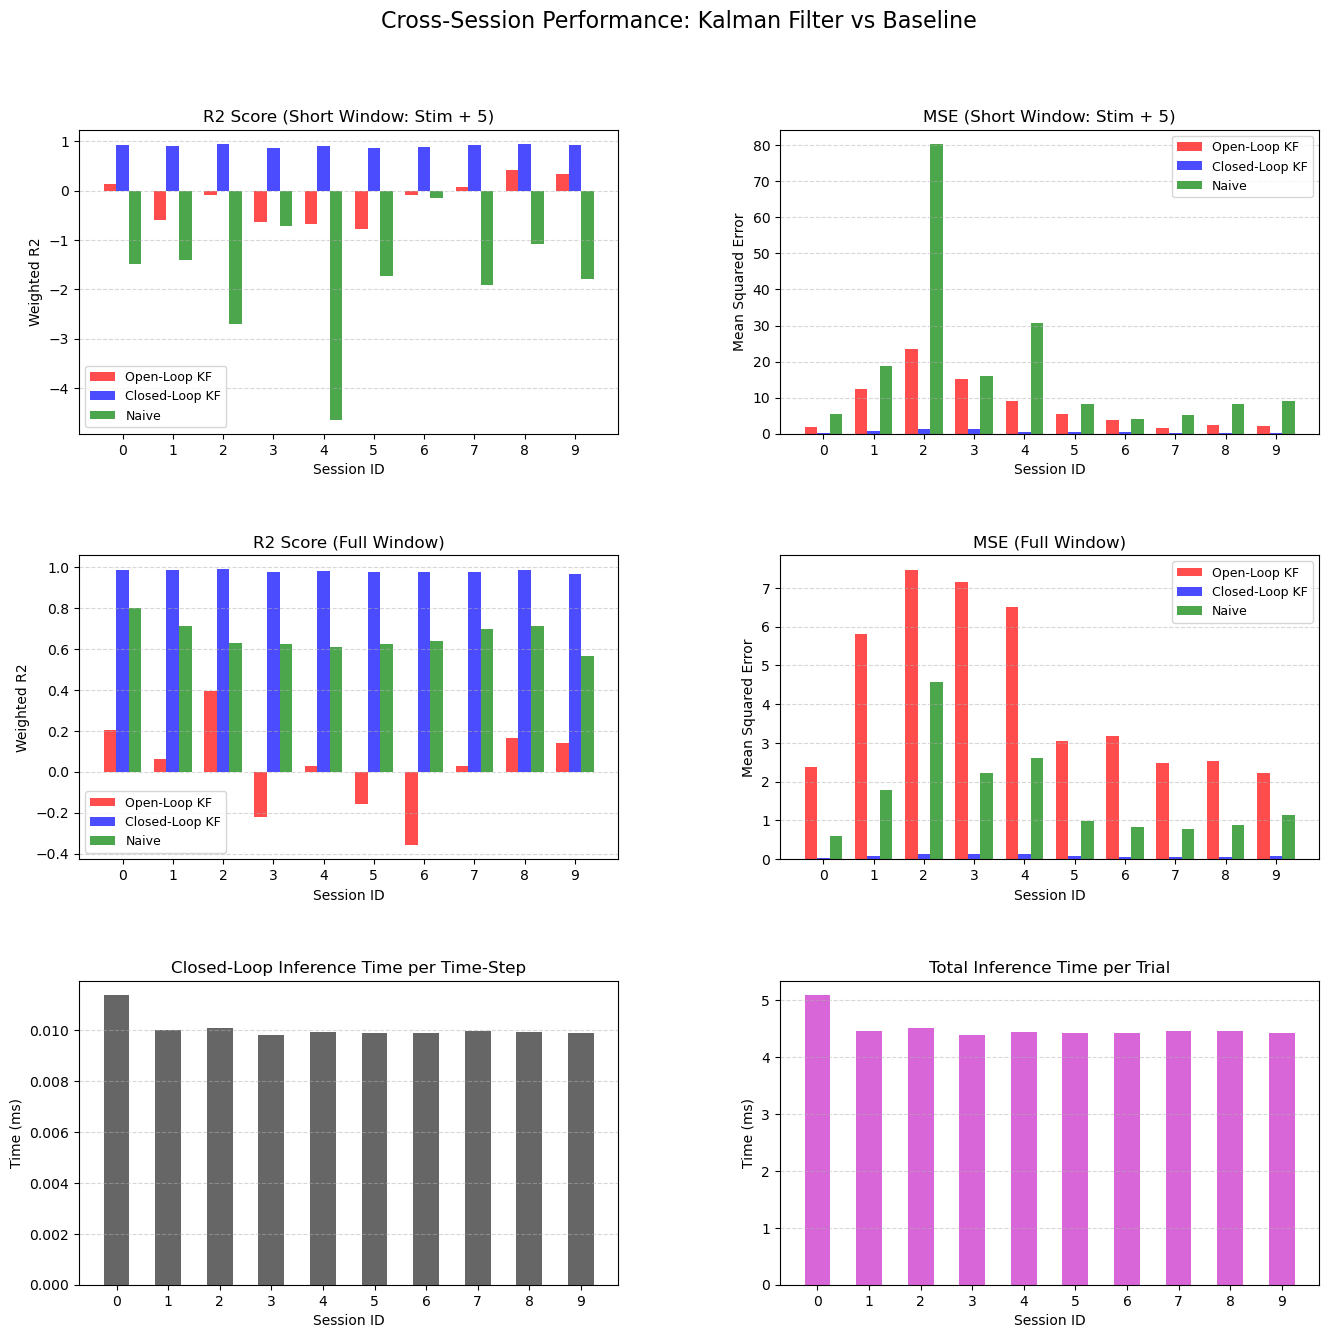

In [47]:
# --- Plotting Cross-Session Results (Bar Charts) ---
ids_list = session_metrics["ids"]  # Renamed to avoid confusion with `id` builtin
n_sessions = len(ids_list)
x = np.arange(n_sessions)
width = 0.25  # width of the bars

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Helper function to plot bars
def plot_grouped_bars(ax, metrics_open, metrics_closed, metrics_naive, title, ylabel):
    rects1 = ax.bar(x - width, metrics_open, width, label='Open-Loop KF', color='red', alpha=0.7)
    rects2 = ax.bar(x, metrics_closed, width, label='Closed-Loop KF', color='blue', alpha=0.7)
    rects3 = ax.bar(x + width, metrics_naive, width, label='Naive', color='green', alpha=0.7)
    
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Session ID')
    ax.set_xticks(x)
    ax.set_xticklabels(ids_list)
    ax.legend(prop={'size': 9})
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 1. R2 - Short Window
plot_grouped_bars(axes[0, 0], 
                  session_metrics["r2_open_short"], 
                  session_metrics["r2_closed_short"], 
                  session_metrics["r2_naive_short"],
                  "R2 Score (Short Window: Stim + 5)", "Weighted R2")

# 2. MSE - Short Window
plot_grouped_bars(axes[0, 1], 
                  session_metrics["mse_open_short"], 
                  session_metrics["mse_closed_short"], 
                  session_metrics["mse_naive_short"],
                  "MSE (Short Window: Stim + 5)", "Mean Squared Error")

# 3. R2 - Full Window
plot_grouped_bars(axes[1, 0], 
                  session_metrics["r2_open_full"], 
                  session_metrics["r2_closed_full"], 
                  session_metrics["r2_naive_full"],
                  "R2 Score (Full Window)", "Weighted R2")

# 4. MSE - Full Window
plot_grouped_bars(axes[1, 1], 
                  session_metrics["mse_open_full"], 
                  session_metrics["mse_closed_full"], 
                  session_metrics["mse_naive_full"],
                  "MSE (Full Window)", "Mean Squared Error")

# 5. Timing - Per Step (Bar Chart)
# Only one series, so simple bar chart
ax = axes[2, 0]
times_ms = np.array(session_metrics["cl_time_per_step"]) * 1e3
ax.bar(x, times_ms, width*2, color='k', alpha=0.6)
ax.set_title("Closed-Loop Inference Time per Time-Step")
ax.set_ylabel("Time (ms)")
ax.set_xlabel("Session ID")
ax.set_xticks(x)
ax.set_xticklabels(ids_list)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 6. Timing - Per Trial (Bar Chart)
ax = axes[2, 1]
trial_times_ms = np.array(session_metrics["inference_time_per_trial"]) * 1e3
ax.bar(x, trial_times_ms, width*2, color='m', alpha=0.6)
ax.set_title("Total Inference Time per Trial")
ax.set_ylabel("Time (ms)")
ax.set_xlabel("Session ID")
ax.set_xticks(x)
ax.set_xticklabels(ids_list)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Cross-Session Performance: Kalman Filter vs Baseline", y=0.96, fontsize=16)
plt.show()